
# CloudCare AI — 2·3·4·5단계 최종 EDA·전처리 기준 노트북

이 노트북은 **최종 합성데이터의 `ML학습용_최종` 시트만 사용**하여 아래 3개 업무를 Python으로 수행합니다.

- **2. Target 분포·Class 불균형 분석**
- **3. Target ↔ Feature EDA**
- **4. Feature ↔ Feature 상관·중복 분석**
- **5. 결측치·이상치·중복 처리 기준 확정**

> **중요:** `Audit_생성원본` 시트에는 숨은 변수, 내부 이탈위험점수, 합성 이탈확률 등 **정답을 만들 때 사용한 정보**가 있으므로 이 분석과 향후 ML 학습에는 사용하지 않습니다.

### 이 노트북에서 얻는 최종 결론
1. 이탈/유지 비율과 Class 불균형 정도
2. Accuracy 단독 사용이 적절한지 여부와 평가 지표 방향
3. 각 Feature가 이탈과 어떤 관계를 보이는지
4. Feature끼리 지나치게 겹치거나 중복되는지
5. 어떤 Feature를 유지해야 하는지에 대한 근거
6. 결측치·이상치·중복을 어떻게 처리할지에 대한 최종 기준

> **해석 주의:** 이 데이터는 합성데이터이므로, 통계검정의 p-value는 “실제 시장에서 인과관계가 증명되었다”는 뜻이 아닙니다.  
> 여기서는 **합성데이터 내부에 의도한 패턴이 잘 구현되었는지 확인하는 용도**로 사용합니다.


#### 코드 셀 1 — 팀원용 설명
### 이 셀은 무엇을 하나요?
분석에 필요한 Python 도구를 한 번에 불러오고, 표와 그래프가 보기 좋게 나오도록 기본 설정을 합니다.

### 왜 필요한가요?
Python 분석에서는 `pandas`로 표를 다루고, `matplotlib`으로 그래프를 그리며, `scipy`와 `sklearn`으로 통계검정과 모델 관련 계산을 합니다. 이 셀은 이후 모든 분석이 작동하도록 준비하는 **환경 설정 단계**입니다.

### 결과를 어떻게 보면 되나요?
마지막에 `분석 환경 준비 완료`가 나오면 정상입니다. 이 셀 자체의 결과를 해석할 필요는 없습니다.

In [1]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 0. 라이브러리 및 시각화 기본 설정
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# ============================================
# 0. 라이브러리 및 시각화 기본 설정
# ============================================
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.linear_model import LinearRegression
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 한글 폰트 자동 설정
font_candidates = [
    "Malgun Gothic",      # Windows
    "AppleGothic",        # macOS
    "NanumGothic",        # Linux/Colab 등
    "Noto Sans CJK KR"
]
available_fonts = {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}

for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False

print("분석 환경 준비 완료")


분석 환경 준비 완료


#### 코드 셀 2 — 팀원용 설명
### 이 셀은 무엇을 하나요?
최종 합성데이터 Excel에서 **`ML학습용_최종` 시트만 읽어옵니다.**

### 왜 이 시트만 사용하나요?
감사용 시트에는 숨은 변수, 내부 위험점수, 합성 이탈확률처럼 **정답을 만들 때 사용한 정보**가 들어 있습니다. 이런 값을 분석이나 모델 학습에 넣으면 정답을 미리 보는 것과 비슷한 **데이터 누수**가 생길 수 있습니다.

### 결과를 어떻게 보면 되나요?
행 수가 약 5,000개인지, 열 수가 예상한 변수 개수와 맞는지, 첫 5행이 정상적으로 보이는지 확인하면 됩니다.

In [2]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 1. 최종 Excel 데이터 불러오기
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# ============================================
# 1. 최종 Excel 데이터 불러오기
# ============================================
FILE_NAME = "CloudCare_AI_Synthetic_Data_EVIDENCE_CALIBRATED_FINAL.xlsx"

candidates = [
    Path(FILE_NAME),
    Path("/mnt/data") / FILE_NAME
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"{FILE_NAME} 파일을 찾을 수 없습니다.\n"
        "이 노트북과 Excel 파일을 같은 폴더에 두고 다시 실행해 주세요."
    )

SHEET_NAME = "ML학습용_최종"
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

print(f"불러온 파일: {DATA_PATH}")
print(f"사용 시트: {SHEET_NAME}")
print(f"행 수: {len(df):,}개")
print(f"열 수: {df.shape[1]}개")

display(df.head())


불러온 파일: CloudCare_AI_Synthetic_Data_EVIDENCE_CALIBRATED_FINAL.xlsx
사용 시트: ML학습용_최종
행 수: 5,000개
열 수: 9개


,customer_id,industry,company_size,budget_overrun_flag,cloud_waste_ratio,usage_change_3m,service_disruption_level,support_issue_level,renewal_churn
0,CC-00001,education_public,small_10_49,NaN,0.1400,0.0556,0.0000,3.0000,1
1,CC-00002,construction_real_estate,small_10_49,0.0000,0.2837,-0.0103,3.0000,3.0000,1
2,CC-00003,it_software,small_10_49,0.0000,0.3104,0.0179,0.0000,0.0000,0
3,CC-00004,wholesale_retail,mid_50_249,0.0000,0.2710,0.0932,0.0000,0.0000,0
4,CC-00005,wholesale_retail,small_10_49,1.0000,0.3644,0.1930,0.0000,0.0000,0



## 데이터에서 사용하는 변수

| 변수 | 쉬운 한국어 의미 | 종류 |
|---|---|---|
| `industry` | 업종 | 범주형 |
| `company_size` | 기업 규모 | 범주형 |
| `budget_overrun_flag` | 클라우드 예산 초과 여부 | 0/1 |
| `cloud_waste_ratio` | 클라우드 비용 낭비율 | 연속형 |
| `usage_change_3m` | 최근 3개월 사용량 변화율 | 연속형 |
| `service_disruption_level` | 서비스 장애 수준 | 0~3 순서형 |
| `support_issue_level` | 고객지원 문제 수준 | 0~3 순서형 |
| `renewal_churn` | 재계약 이탈 여부 | **Target** |

`renewal_churn = 1`은 **재계약 이탈**, `0`은 **재계약 유지**입니다.


#### 코드 셀 3 — 팀원용 설명
### 이 셀은 무엇을 하나요?
각 변수의 **데이터형, 결측 개수, 결측률, 고유값 수**를 한 번에 확인합니다.

### 왜 필요한가요?
분석 전에 “숫자로 되어 있어야 할 값이 문자로 들어가 있지는 않은지”, “값이 많이 비어 있지는 않은지”, “범주가 몇 개인지”를 먼저 확인해야 합니다.

### 결과를 어떻게 보면 되나요?
- `데이터형`: 숫자형인지 문자형인지 확인
- `결측률(%)`: 값이 비어 있는 비율
- `고유값수`: 예를 들어 `renewal_churn`은 0/1 두 값이므로 보통 2가 나와야 합니다.

In [3]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 데이터 기본 구조 확인
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 데이터 기본 구조 확인
summary = pd.DataFrame({
    "데이터형": df.dtypes.astype(str),
    "결측개수": df.isna().sum(),
    "결측률(%)": (df.isna().mean() * 100).round(2),
    "고유값수": df.nunique(dropna=True)
})
display(summary)


,데이터형,결측개수,결측률(%),고유값수
customer_id,object,0,0.0000,5000
industry,object,0,0.0000,9
company_size,object,0,0.0000,3
budget_overrun_flag,float64,79,1.5800,2
cloud_waste_ratio,float64,91,1.8200,2683
usage_change_3m,float64,94,1.8800,3332
service_disruption_level,float64,93,1.8600,4
support_issue_level,float64,72,1.4400,4
renewal_churn,int64,0,0.0000,2



# 2. Target 분포 · Class 불균형 분석

먼저 **재계약 유지(0)** 와 **이탈(1)** 이 몇 개인지 확인합니다.

Class 불균형이란 한쪽 정답이 다른 쪽보다 훨씬 많은 상태를 뜻합니다.  
이 경우 **Accuracy(정확도)만 보면 모델 성능을 잘못 판단할 수 있습니다.**


#### 코드 셀 4 — 팀원용 설명
### 이 셀은 무엇을 하나요?
목표값인 `renewal_churn`의 **유지(0)와 이탈(1) 고객 수 및 비율**을 계산합니다.

### 왜 필요한가요?
이탈 고객이 너무 적으면 모델이 대부분을 “유지”라고만 예측해도 높은 정확도가 나올 수 있습니다. 그래서 먼저 **Class 불균형** 정도를 확인해야 합니다.

### 결과를 어떻게 보면 되나요?
- 이탈률이 전체 중 몇 %인지 확인합니다.
- `유지 : 이탈 비율`이 너무 크게 벌어지는지 봅니다.
- `모두 유지라고 예측했을 때의 Accuracy`는 이후 모델이 반드시 넘어야 할 최소 기준선으로 볼 수 있습니다.

In [4]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 2-1. Target 개수와 비율
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 2-1. Target 개수와 비율
target = "renewal_churn"

target_count = df[target].value_counts().sort_index()
target_ratio = df[target].value_counts(normalize=True).sort_index()

target_table = pd.DataFrame({
    "구분": ["재계약 유지(0)", "재계약 이탈(1)"],
    "고객 수": [target_count.get(0, 0), target_count.get(1, 0)],
    "비율(%)": [target_ratio.get(0, 0)*100, target_ratio.get(1, 0)*100]
})

display(target_table.style.format({"고객 수":"{:,.0f}", "비율(%)":"{:.2f}%"}))

majority_accuracy = target_count.max() / len(df)
imbalance_ratio = target_count.get(0, 0) / target_count.get(1, 1)

print(f"이탈률: {target_ratio.get(1, 0)*100:.2f}%")
print(f"유지율: {target_ratio.get(0, 0)*100:.2f}%")
print(f"유지 : 이탈 비율 ≈ {imbalance_ratio:.2f} : 1")
print(f"모든 고객을 '유지'라고만 예측해도 Accuracy = {majority_accuracy*100:.2f}%")


,구분,고객 수,비율(%)
0,재계약 유지(0),"4,086",81.72%
1,재계약 이탈(1),914,18.28%


이탈률: 18.28%
유지율: 81.72%
유지 : 이탈 비율 ≈ 4.47 : 1
모든 고객을 '유지'라고만 예측해도 Accuracy = 81.72%


#### 코드 셀 5 — 팀원용 설명
### 이 셀은 무엇을 하나요?
재계약 유지 고객과 이탈 고객의 **실제 개수 차이**를 막대그래프로 보여줍니다.

### 왜 필요한가요?
숫자 표만 보는 것보다 두 집단의 크기 차이를 훨씬 직관적으로 이해할 수 있습니다.

### 그래프 읽는 법
두 막대의 높이 차이가 클수록 Class 불균형이 큰 것입니다. 이 그래프에서는 유지 고객이 이탈 고객보다 많다는 점을 확인하면 됩니다.

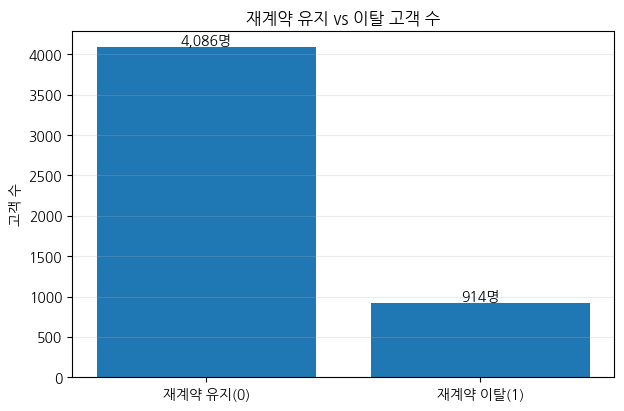

In [5]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 2-2. Target 고객 수 시각화
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 2-2. Target 고객 수 시각화
labels = ["재계약 유지(0)", "재계약 이탈(1)"]
values = [target_count.get(0, 0), target_count.get(1, 0)]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(labels, values)
plt.title("재계약 유지 vs 이탈 고객 수")
plt.ylabel("고객 수")
plt.grid(axis="y", alpha=0.25)

for bar, v in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, v+40, f"{v:,}명", ha="center")

plt.show()


#### 코드 셀 6 — 팀원용 설명
### 이 셀은 무엇을 하나요?
유지/이탈을 **비율(%)** 기준으로 다시 보여줍니다.

### 왜 필요한가요?
고객 수는 전체 데이터 크기에 따라 달라지지만, 비율은 데이터가 바뀌어도 비교하기 쉬운 기준입니다.

### 그래프 읽는 법
이탈 막대가 약 20% 안팎이라면 “다수의 유지 고객과 소수의 이탈 고객” 구조라고 이해하면 됩니다.

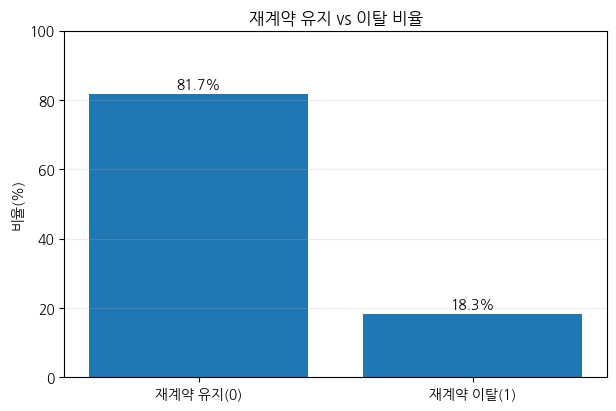

In [6]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 2-3. Target 비율 시각화
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 2-3. Target 비율 시각화
plt.figure(figsize=(7, 4.5))
bars = plt.bar(
    ["재계약 유지(0)", "재계약 이탈(1)"],
    [target_ratio.get(0,0)*100, target_ratio.get(1,0)*100]
)
plt.title("재계약 유지 vs 이탈 비율")
plt.ylabel("비율(%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)

for bar, v in zip(bars, [target_ratio.get(0,0)*100, target_ratio.get(1,0)*100]):
    plt.text(bar.get_x()+bar.get_width()/2, v+1.5, f"{v:.1f}%", ha="center")

plt.show()


#### 코드 셀 7 — 팀원용 설명
### 이 셀은 무엇을 하나요?
향후 모델 성능을 평가할 때 사용할 **Accuracy, Recall, Precision, F1, ROC-AUC, PR-AUC**의 의미를 쉬운 말로 정리합니다.

### 왜 필요한가요?
이탈 고객이 적기 때문에 Accuracy만 보면 잘못된 판단을 할 수 있습니다.

### 핵심
이 프로젝트에서는 특히 **실제 이탈 고객을 얼마나 잘 찾아내는가(Recall)** 와 **이탈이라고 예측한 고객 중 실제 이탈이 얼마나 되는가(Precision)** 를 함께 봐야 합니다.

In [7]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 2-4. 평가 지표 방향
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 2-4. 평가 지표 방향
metric_guide = pd.DataFrame([
    ["Accuracy(정확도)", "전체 중 맞힌 비율", "보조 지표", "유지 고객이 많아 단독 사용 시 과대평가 가능"],
    ["Recall(재현율)", "실제 이탈 고객 중 얼마나 찾아냈는지", "중요", "이탈 고객을 놓치지 않는 것이 서비스 목적과 직접 연결"],
    ["Precision(정밀도)", "이탈이라고 예측한 고객 중 실제 이탈 비율", "중요", "불필요한 관리 대상이 너무 많아지는 것을 방지"],
    ["F1-score", "Recall과 Precision의 균형", "중요", "한쪽 지표만 좋아지는 문제를 보완"],
    ["ROC-AUC", "두 Class를 전반적으로 구분하는 능력", "중요", "모델 간 전체적인 분류력 비교에 유용"],
    ["PR-AUC", "이탈 Class 중심의 Precision-Recall 성능", "특히 중요", "불균형 데이터에서 양성(이탈) 탐지력을 보기 좋음"]
], columns=["평가지표", "쉬운 의미", "권장도", "이 프로젝트에서의 이유"])

display(metric_guide)

print(
    f"결론: 이 데이터는 이탈이 {target_ratio.get(1,0)*100:.1f}%로 유지보다 적습니다.\n"
    f"따라서 Accuracy만 사용하지 말고 Recall, Precision, F1, ROC-AUC, PR-AUC를 함께 보는 것이 적절합니다."
)


,평가지표,쉬운 의미,권장도,이 프로젝트에서의 이유
0,Accuracy(정확도),전체 중 맞힌 비율,보조 지표,유지 고객이 많아 단독 사용 시 과대평가 가능
1,Recall(재현율),실제 이탈 고객 중 얼마나 찾아냈는지,중요,이탈 고객을 놓치지 않는 것이 서비스 목적과 직접 연결
2,Precision(정밀도),이탈이라고 예측한 고객 중 실제 이탈 비율,중요,불필요한 관리 대상이 너무 많아지는 것을 방지
3,F1-score,Recall과 Precision의 균형,중요,한쪽 지표만 좋아지는 문제를 보완
4,ROC-AUC,두 Class를 전반적으로 구분하는 능력,중요,모델 간 전체적인 분류력 비교에 유용
5,PR-AUC,이탈 Class 중심의 Precision-Recall 성능,특히 중요,불균형 데이터에서 양성(이탈) 탐지력을 보기 좋음


결론: 이 데이터는 이탈이 18.3%로 유지보다 적습니다.
따라서 Accuracy만 사용하지 말고 Recall, Precision, F1, ROC-AUC, PR-AUC를 함께 보는 것이 적절합니다.



# 3. Target ↔ Feature EDA

이 단계의 질문은 매우 단순합니다.

> **“어떤 특징을 가진 고객이 재계약 이탈을 더 많이 하는가?”**

분석 방식은 변수 종류에 따라 다르게 적용합니다.

- **범주형·순서형 변수** → 그룹별 이탈률, 교차표, 카이제곱 검정
- **연속형 변수** → 유지/이탈 그룹의 평균·중앙값·분포, 구간별 이탈률, Mann–Whitney U 검정


#### 코드 셀 8 — 팀원용 설명
### 이 셀은 무엇을 하나요?
7개 Feature를 **범주형/순서형**과 **연속형**으로 나누고, 그래프와 표에서 사용할 쉬운 한국어 이름을 지정합니다.

### 왜 필요한가요?
변수 종류에 따라 분석 방법이 달라집니다. 예를 들어 업종처럼 범주로 나뉘는 변수와 비용 낭비율처럼 숫자가 연속적으로 움직이는 변수는 같은 방식으로 분석하면 안 됩니다.

### 결과
화면에 특별한 출력이 없어도 정상입니다. 이후 셀에서 이 설정을 계속 재사용합니다.

In [8]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 분석 대상 변수 구분
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 분석 대상 변수 구분
categorical_features = [
    "industry",
    "company_size",
    "budget_overrun_flag",
    "service_disruption_level",
    "support_issue_level"
]

continuous_features = [
    "cloud_waste_ratio",
    "usage_change_3m"
]

ko_name = {
    "industry": "업종",
    "company_size": "기업 규모",
    "budget_overrun_flag": "예산 초과 여부",
    "cloud_waste_ratio": "클라우드 비용 낭비율",
    "usage_change_3m": "최근 3개월 사용량 변화율",
    "service_disruption_level": "서비스 장애 수준",
    "support_issue_level": "고객지원 문제 수준",
    "renewal_churn": "재계약 이탈"
}

# 보기 좋은 한글 값 변환
value_label_map = {
    "company_size": {
        "small_10_49": "소규모(10~49인)",
        "mid_50_249": "중규모(50~249인)",
        "large_250_plus": "대규모(250인 이상)"
    },
    "budget_overrun_flag": {
        0.0: "예산 정상",
        1.0: "예산 초과"
    },
    "service_disruption_level": {
        0.0: "0단계",
        1.0: "1단계",
        2.0: "2단계",
        3.0: "3단계"
    },
    "support_issue_level": {
        0.0: "0단계",
        1.0: "1단계",
        2.0: "2단계",
        3.0: "3단계"
    }
}


#### 코드 셀 9 — 팀원용 설명
### 이 셀은 무엇을 하나요?
업종, 기업 규모, 예산 초과 여부, 장애 수준, 고객지원 문제 수준별로 **고객 수·이탈 고객 수·이탈률**을 계산합니다.

### 왜 필요한가요?
“어떤 그룹에서 이탈이 더 많이 발생하는가?”를 가장 직접적으로 확인할 수 있는 표입니다.

### 표 읽는 법
예를 들어 장애 3단계의 이탈률이 장애 0단계보다 높다면, 합성데이터 안에서 장애 심각도가 이탈위험과 같은 방향으로 움직인다고 볼 수 있습니다.

In [9]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-1. 범주형 Feature별 고객 수·이탈 수·이탈률 피벗테이블
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-1. 범주형 Feature별 고객 수·이탈 수·이탈률 피벗테이블

categorical_tables = {}

for feature in categorical_features:
    temp = (
        df.groupby(feature, dropna=False)[target]
          .agg(고객수="count", 이탈고객수="sum", 이탈률="mean")
          .reset_index()
    )
    temp["이탈률(%)"] = temp["이탈률"] * 100
    temp = temp.drop(columns="이탈률").sort_values("이탈률(%)", ascending=False)

    if feature in value_label_map:
        temp[feature] = temp[feature].map(value_label_map[feature]).fillna(temp[feature])

    categorical_tables[feature] = temp

    display(Markdown(f"### {ko_name[feature]}별 이탈률"))
    display(temp.style.format({"고객수":"{:,.0f}", "이탈고객수":"{:,.0f}", "이탈률(%)":"{:.2f}%"}))


### 업종별 이탈률

,industry,고객수,이탈고객수,이탈률(%)
4,it_software,354,76,21.47%
8,wholesale_retail,653,132,20.21%
0,construction_real_estate,847,163,19.24%
5,manufacturing,"1,645",312,18.97%
3,healthcare,366,62,16.94%
1,education_public,63,10,15.87%
6,professional_services,805,127,15.78%
7,transport_logistics,187,29,15.51%
2,finance_insurance,80,3,3.75%


### 기업 규모별 이탈률

,company_size,고객수,이탈고객수,이탈률(%)
2,소규모(10~49인),"2,580",536,20.78%
1,중규모(50~249인),"1,962",311,15.85%
0,대규모(250인 이상),458,67,14.63%


### 예산 초과 여부별 이탈률

,budget_overrun_flag,고객수,이탈고객수,이탈률(%)
1,예산 초과,862,271,31.44%
2,nan,79,15,18.99%
0,예산 정상,"4,059",628,15.47%


### 서비스 장애 수준별 이탈률

,service_disruption_level,고객수,이탈고객수,이탈률(%)
3,3단계,290,129,44.48%
2,2단계,711,245,34.46%
1,1단계,"1,195",224,18.74%
4,nan,93,11,11.83%
0,0단계,"2,711",305,11.25%


### 고객지원 문제 수준별 이탈률

,support_issue_level,고객수,이탈고객수,이탈률(%)
3,3단계,241,133,55.19%
2,2단계,511,184,36.01%
1,1단계,"1,115",225,20.18%
0,0단계,"3,061",367,11.99%
4,nan,72,5,6.94%


#### 코드 셀 10 — 팀원용 설명
### 이 셀은 무엇을 하나요?
업종별 재계약 이탈률을 가로 막대그래프로 비교합니다.

### 왜 필요한가요?
업종별로 서비스 이용 특성과 비용 구조가 다를 수 있으므로 이탈률에도 차이가 있는지 확인합니다.

### 그래프 읽는 법
막대가 길수록 해당 업종의 이탈률이 높습니다. 다만 업종 차이가 있다고 해서 업종 자체가 이탈의 원인이라고 단정하면 안 됩니다.

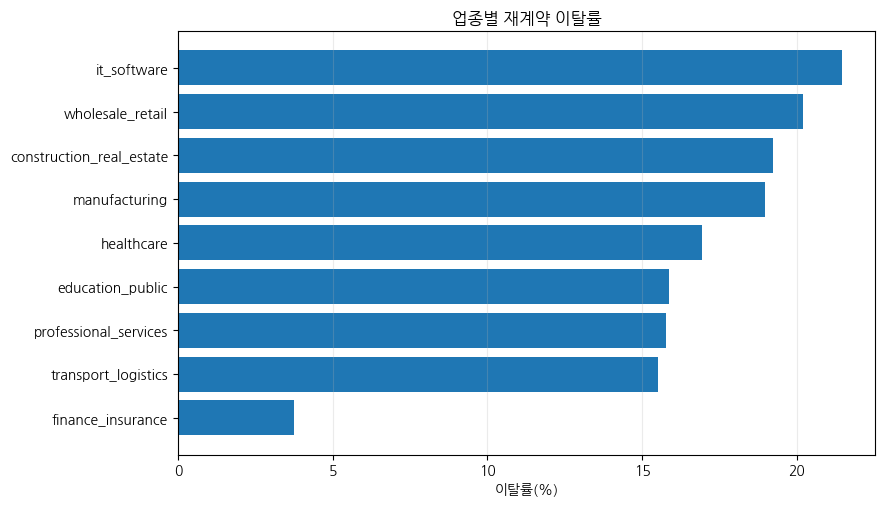

In [10]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-2. 업종별 이탈률 그래프
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-2. 업종별 이탈률 그래프
t = categorical_tables["industry"].sort_values("이탈률(%)", ascending=True)

plt.figure(figsize=(9, 5.5))
plt.barh(t["industry"].astype(str), t["이탈률(%)"])
plt.title("업종별 재계약 이탈률")
plt.xlabel("이탈률(%)")
plt.grid(axis="x", alpha=0.25)
plt.show()


#### 코드 셀 11 — 팀원용 설명
### 이 셀은 무엇을 하나요?
소규모·중규모·대규모 고객사의 이탈률을 비교합니다.

### 왜 필요한가요?
기업 규모에 따라 계약 규모, 내부 IT 인력, 클라우드 운영 방식이 달라질 수 있기 때문입니다.

### 그래프 읽는 법
세 막대 중 어느 규모에서 이탈률이 높은지 확인합니다. 차이가 크지 않더라도 기업 규모는 중요한 고객 특성이므로 바로 제거하지 않습니다.

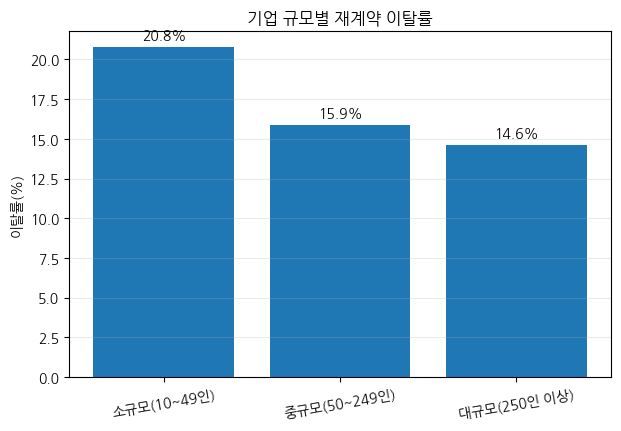

In [11]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-3. 기업 규모별 이탈률 그래프
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-3. 기업 규모별 이탈률 그래프
t = categorical_tables["company_size"]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(t["company_size"].astype(str), t["이탈률(%)"])
plt.title("기업 규모별 재계약 이탈률")
plt.ylabel("이탈률(%)")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.25)

for b, v in zip(bars, t["이탈률(%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.1f}%", ha="center")

plt.show()


#### 코드 셀 12 — 팀원용 설명
### 이 셀은 무엇을 하나요?
클라우드 예산을 초과한 고객과 그렇지 않은 고객의 이탈률을 비교합니다.

### 왜 필요한가요?
예산 초과는 비용 부담을 직접 보여주는 신호이므로 재계약에 영향을 줄 가능성이 있습니다.

### 그래프 읽는 법
`예산 초과` 막대가 더 높다면, 비용 부담이 큰 고객에서 이탈이 더 많이 발생하도록 데이터가 설계되었음을 확인할 수 있습니다.

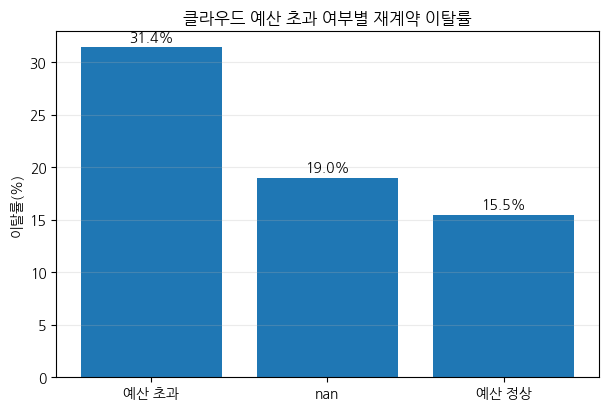

In [12]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-4. 예산 초과 여부별 이탈률 그래프
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-4. 예산 초과 여부별 이탈률 그래프
t = categorical_tables["budget_overrun_flag"]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(t["budget_overrun_flag"].astype(str), t["이탈률(%)"])
plt.title("클라우드 예산 초과 여부별 재계약 이탈률")
plt.ylabel("이탈률(%)")
plt.grid(axis="y", alpha=0.25)

for b, v in zip(bars, t["이탈률(%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.6, f"{v:.1f}%", ha="center")

plt.show()


#### 코드 셀 13 — 팀원용 설명
### 이 셀은 무엇을 하나요?
서비스 장애 수준 0~3단계별 재계약 이탈률을 비교합니다.

### 왜 필요한가요?
장애가 심해질수록 고객 불만과 계약 재검토 가능성이 높아지는 구조가 합성데이터에 잘 반영되었는지 확인합니다.

### 그래프 읽는 법
0단계 → 3단계로 갈수록 막대가 커지는지 확인합니다. 단계가 높을수록 이탈률도 높다면 의도한 위험 구조가 잘 구현된 것입니다.

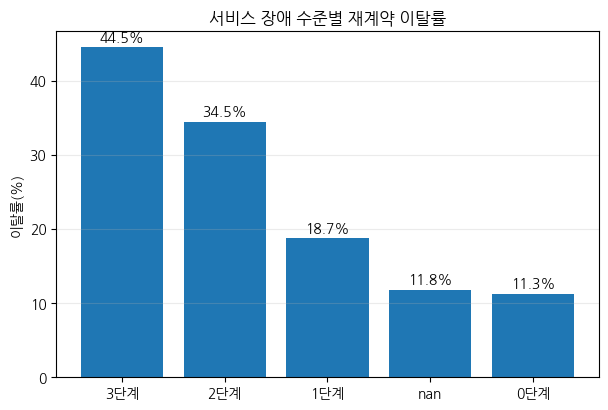

In [13]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-5. 서비스 장애 수준별 이탈률 그래프
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-5. 서비스 장애 수준별 이탈률 그래프
t = categorical_tables["service_disruption_level"]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(t["service_disruption_level"].astype(str), t["이탈률(%)"])
plt.title("서비스 장애 수준별 재계약 이탈률")
plt.ylabel("이탈률(%)")
plt.grid(axis="y", alpha=0.25)

for b, v in zip(bars, t["이탈률(%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.8, f"{v:.1f}%", ha="center")

plt.show()


#### 코드 셀 14 — 팀원용 설명
### 이 셀은 무엇을 하나요?
고객지원 문제 수준 0~3단계에 따라 이탈률이 어떻게 달라지는지 확인합니다.

### 왜 필요한가요?
기술지원 지연, 미해결 문의, SLA 문제 등이 심해지면 고객 경험이 악화될 수 있기 때문입니다.

### 그래프 읽는 법
지원 문제 단계가 높아질수록 이탈률이 증가하는지 봅니다.

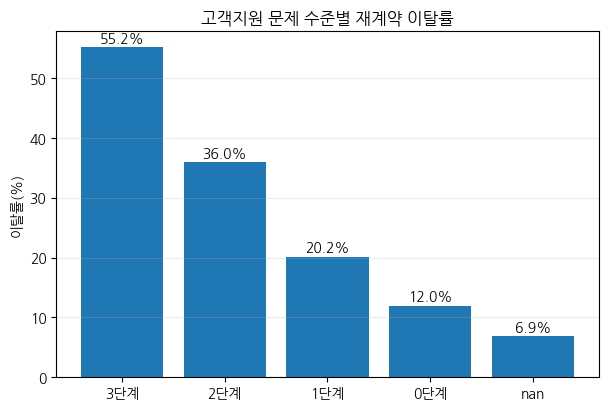

In [14]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-6. 고객지원 문제 수준별 이탈률 그래프
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-6. 고객지원 문제 수준별 이탈률 그래프
t = categorical_tables["support_issue_level"]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(t["support_issue_level"].astype(str), t["이탈률(%)"])
plt.title("고객지원 문제 수준별 재계약 이탈률")
plt.ylabel("이탈률(%)")
plt.grid(axis="y", alpha=0.25)

for b, v in zip(bars, t["이탈률(%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.8, f"{v:.1f}%", ha="center")

plt.show()


#### 코드 셀 15 — 팀원용 설명
### 이 셀은 무엇을 하나요?
범주형 Feature와 이탈 여부 사이에 **통계적으로 차이가 있는지** 카이제곱 검정으로 확인하고, 관계의 크기를 `Cramer's V`로 계산합니다.

### 용어를 쉽게 설명하면
- **p-value**: 지금 보이는 차이가 단순한 우연일 가능성을 판단하는 참고값
- **Cramer's V**: 관계가 얼마나 강한지 보는 값. 0에 가까울수록 약하고 커질수록 강합니다.

### 주의
이 데이터는 합성데이터이므로 p-value가 작다고 해서 실제 시장에서 인과관계가 증명되었다고 해석하면 안 됩니다.

In [15]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-7. 범주형 Feature ↔ Target 통계검정
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-7. 범주형 Feature ↔ Target 통계검정
# 카이제곱: "그룹에 따라 이탈/유지 비율 차이가 있는가?"
# Cramer's V: 관계의 크기가 어느 정도인가? (0에 가까우면 약함)

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape

    # 표본 크기 보정
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)

    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

cat_test_rows = []

for feature in categorical_features:
    sub = df[[feature, target]].dropna()
    ct = pd.crosstab(sub[feature], sub[target])
    chi2, p, dof, expected = chi2_contingency(ct)
    v = cramers_v(sub[feature], sub[target])

    cat_test_rows.append([
        ko_name[feature],
        chi2,
        p,
        v,
        "유의" if p < 0.05 else "유의하지 않음"
    ])

cat_test = pd.DataFrame(
    cat_test_rows,
    columns=["Feature", "카이제곱 통계량", "p-value", "Cramer's V", "p<0.05 여부"]
)

display(cat_test.style.format({
    "카이제곱 통계량":"{:.3f}",
    "p-value":"{:.4g}",
    "Cramer's V":"{:.3f}"
}))

print("읽는 법:")
print("- p-value < 0.05: 합성데이터 내부에서 그룹별 이탈률 차이가 우연만으로 설명되기 어렵다는 뜻")
print("- Cramer's V가 클수록 Target과의 관계가 상대적으로 큼")
print("- 단, 합성데이터이므로 실제 시장의 인과관계를 증명하는 결과로 해석하면 안 됨")


,Feature,카이제곱 통계량,p-value,Cramer's V,p<0.05 여부
0,업종,21.422,0.006107,0.052,유의
1,기업 규모,22.588,1.245e-05,0.064,유의
2,예산 초과 여부,120.330,5.355e-28,0.156,유의
3,서비스 장애 수준,345.873,1.168e-74,0.264,유의
4,고객지원 문제 수준,408.073,3.948e-88,0.287,유의


읽는 법:
- p-value < 0.05: 합성데이터 내부에서 그룹별 이탈률 차이가 우연만으로 설명되기 어렵다는 뜻
- Cramer's V가 클수록 Target과의 관계가 상대적으로 큼
- 단, 합성데이터이므로 실제 시장의 인과관계를 증명하는 결과로 해석하면 안 됨


#### 코드 셀 16 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비율과 사용량 변화율을 유지 고객과 이탈 고객으로 나누어 평균·중앙값·표준편차·최솟값·최댓값 등을 비교합니다.

### 왜 필요한가요?
이탈 고객의 평균 비용 낭비율이 더 높은지, 사용량 변화율이 더 낮은지처럼 **숫자 자체의 차이**를 확인하기 위해서입니다.

### 표 읽는 법
`유지(0)`와 `이탈(1)` 행의 평균과 중앙값을 비교하면 됩니다.

In [16]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-8. 연속형 Feature: 유지 vs 이탈 통계 요약
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-8. 연속형 Feature: 유지 vs 이탈 통계 요약
continuous_summary = []

for feature in continuous_features:
    for churn_value in [0, 1]:
        s = df.loc[df[target] == churn_value, feature].dropna()
        continuous_summary.append([
            ko_name[feature],
            "유지(0)" if churn_value == 0 else "이탈(1)",
            len(s),
            s.mean(),
            s.median(),
            s.std(),
            s.quantile(0.25),
            s.quantile(0.75),
            s.min(),
            s.max()
        ])

continuous_summary = pd.DataFrame(
    continuous_summary,
    columns=[
        "Feature", "Target", "유효 데이터 수", "평균", "중앙값",
        "표준편차", "25% 지점", "75% 지점", "최솟값", "최댓값"
    ]
)

display(continuous_summary.style.format({
    "유효 데이터 수":"{:,.0f}",
    "평균":"{:.4f}",
    "중앙값":"{:.4f}",
    "표준편차":"{:.4f}",
    "25% 지점":"{:.4f}",
    "75% 지점":"{:.4f}",
    "최솟값":"{:.4f}",
    "최댓값":"{:.4f}"
}))


,Feature,Target,유효 데이터 수,평균,중앙값,표준편차,25% 지점,75% 지점,최솟값,최댓값
0,클라우드 비용 낭비율,유지(0),"4,011",0.2836,0.2761,0.0937,0.2157,0.3436,0.0396,0.6800
1,클라우드 비용 낭비율,이탈(1),898,0.3128,0.3089,0.1007,0.2371,0.3791,0.0379,0.6231
2,최근 3개월 사용량 변화율,유지(0),"4,006",0.0035,0.0116,0.1604,-0.0798,0.0932,-0.5788,0.6001
3,최근 3개월 사용량 변화율,이탈(1),900,-0.0332,-0.0166,0.1818,-0.1537,0.0860,-0.5870,0.4238


#### 코드 셀 17 — 팀원용 설명
### 이 셀은 무엇을 하나요?
유지 고객과 이탈 고객의 **클라우드 비용 낭비율 전체 분포**를 겹쳐서 보여줍니다.

### 왜 필요한가요?
평균만 비교하면 전체 모양을 놓칠 수 있습니다. 이 그래프는 두 집단의 값이 어느 범위에 많이 몰려 있는지 보여줍니다.

### 그래프 읽는 법
이탈 고객의 분포가 유지 고객보다 오른쪽(높은 낭비율)으로 이동해 있다면 비용 낭비가 높은 고객에서 이탈이 더 자주 나타난다는 뜻입니다.

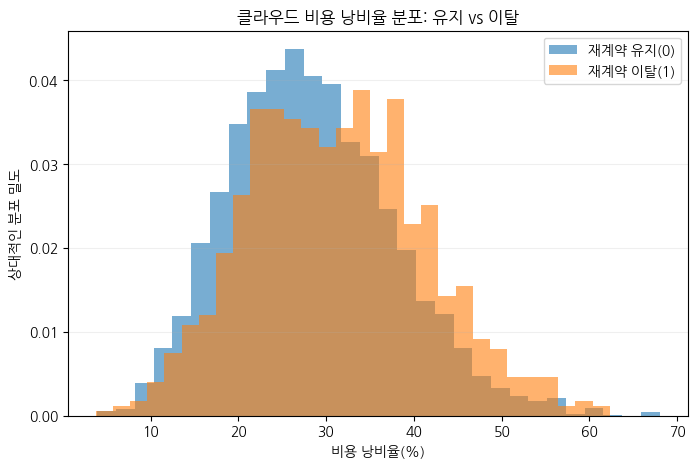

In [17]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-9. 비용 낭비율 분포: 유지 vs 이탈
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-9. 비용 낭비율 분포: 유지 vs 이탈
feature = "cloud_waste_ratio"

plt.figure(figsize=(8, 5))
plt.hist(
    df.loc[df[target]==0, feature].dropna() * 100,
    bins=30, alpha=0.60, label="재계약 유지(0)", density=True
)
plt.hist(
    df.loc[df[target]==1, feature].dropna() * 100,
    bins=30, alpha=0.60, label="재계약 이탈(1)", density=True
)
plt.title("클라우드 비용 낭비율 분포: 유지 vs 이탈")
plt.xlabel("비용 낭비율(%)")
plt.ylabel("상대적인 분포 밀도")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()


#### 코드 셀 18 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비율을 Boxplot으로 요약해 유지/이탈 고객의 중앙값과 분포 폭을 비교합니다.

### Boxplot을 쉽게 읽는 법
- 상자 안의 선: 중앙값
- 상자: 데이터의 가운데 50% 범위
- 바깥쪽 점/수염: 비교적 극단적인 값

이탈 그룹의 상자가 더 높은 위치에 있으면 이탈 고객의 비용 낭비율이 전반적으로 더 높다는 의미입니다.

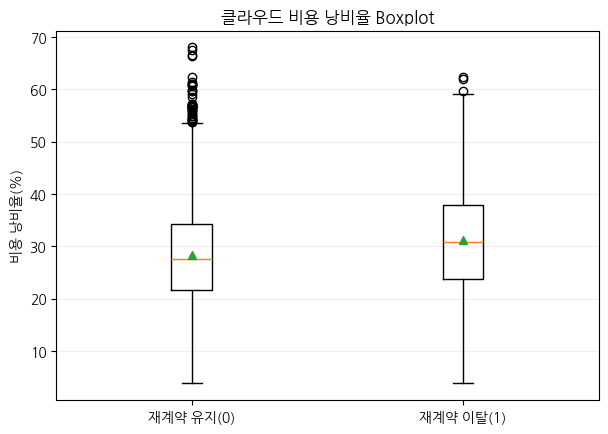

In [18]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-10. 비용 낭비율 Boxplot
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-10. 비용 낭비율 Boxplot
feature = "cloud_waste_ratio"

group0 = df.loc[df[target]==0, feature].dropna() * 100
group1 = df.loc[df[target]==1, feature].dropna() * 100

plt.figure(figsize=(7, 4.8))
plt.boxplot([group0, group1], labels=["재계약 유지(0)", "재계약 이탈(1)"], showmeans=True)
plt.title("클라우드 비용 낭비율 Boxplot")
plt.ylabel("비용 낭비율(%)")
plt.grid(axis="y", alpha=0.2)
plt.show()


#### 코드 셀 19 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비율을 5개 구간으로 나눈 뒤 각 구간의 이탈률을 계산합니다.

### 왜 필요한가요?
연속형 숫자를 구간으로 바꾸면 “낭비율이 낮은 고객 → 높은 고객” 순서로 이탈률이 어떻게 변하는지 쉽게 볼 수 있습니다.

### 그래프 읽는 법
왼쪽에서 오른쪽으로 갈수록 이탈률이 올라가면 비용 낭비율과 이탈위험이 같은 방향으로 움직인다고 볼 수 있습니다.

,비용낭비_5분위,고객수,이탈률(%)
0,매우 낮음,985,12.69%
1,낮음,981,16.72%
2,중간,979,16.04%
3,높음,982,18.64%
4,매우 높음,982,27.39%


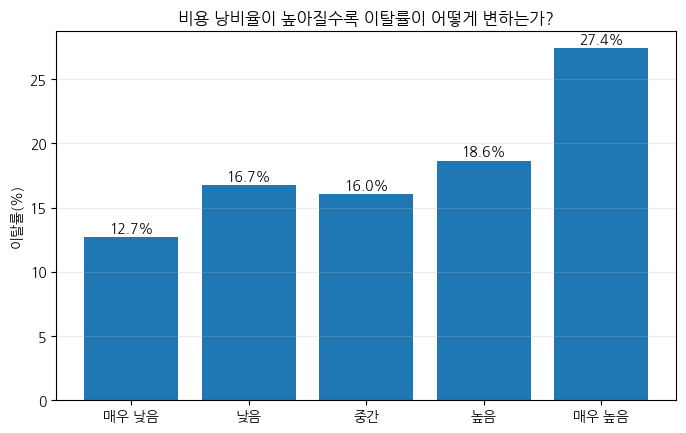

In [19]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-11. 비용 낭비율 구간별 이탈률
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-11. 비용 낭비율 구간별 이탈률
temp = df[[feature, target]].dropna().copy()
temp["비용낭비_5분위"] = pd.qcut(
    temp[feature], q=5,
    labels=["매우 낮음", "낮음", "중간", "높음", "매우 높음"]
)

waste_bin = (
    temp.groupby("비용낭비_5분위", observed=False)[target]
        .agg(고객수="count", 이탈률="mean")
        .reset_index()
)
waste_bin["이탈률(%)"] = waste_bin["이탈률"] * 100

display(waste_bin.drop(columns="이탈률").style.format({
    "고객수":"{:,.0f}",
    "이탈률(%)":"{:.2f}%"
}))

plt.figure(figsize=(8, 4.8))
bars = plt.bar(waste_bin["비용낭비_5분위"].astype(str), waste_bin["이탈률(%)"])
plt.title("비용 낭비율이 높아질수록 이탈률이 어떻게 변하는가?")
plt.ylabel("이탈률(%)")
plt.grid(axis="y", alpha=0.25)
for b, v in zip(bars, waste_bin["이탈률(%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha="center")
plt.show()


#### 코드 셀 20 — 팀원용 설명
### 이 셀은 무엇을 하나요?
최근 3개월 클라우드 사용량 변화율을 유지/이탈 고객으로 나누어 분포를 비교합니다.

### 그래프 읽는 법
- 0보다 왼쪽: 사용량 감소
- 0보다 오른쪽: 사용량 증가
- 이탈 고객이 왼쪽에 더 많이 몰리면 사용량 감소가 이탈과 관련된 신호라는 뜻입니다.

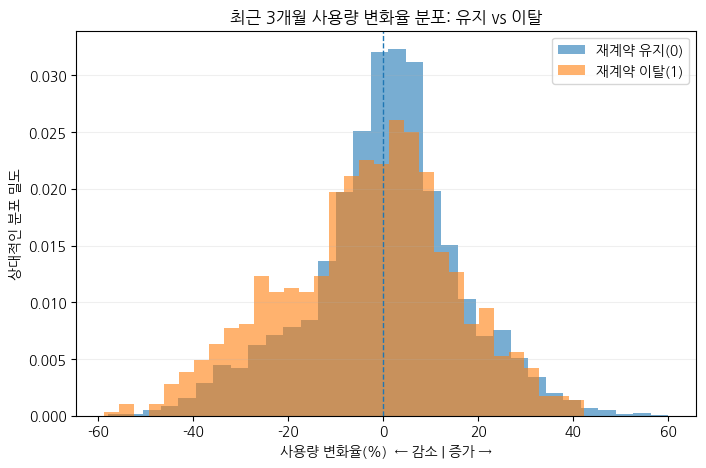

In [20]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-12. 최근 3개월 사용량 변화 분포: 유지 vs 이탈
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-12. 최근 3개월 사용량 변화 분포: 유지 vs 이탈
feature = "usage_change_3m"

plt.figure(figsize=(8, 5))
plt.hist(
    df.loc[df[target]==0, feature].dropna() * 100,
    bins=32, alpha=0.60, label="재계약 유지(0)", density=True
)
plt.hist(
    df.loc[df[target]==1, feature].dropna() * 100,
    bins=32, alpha=0.60, label="재계약 이탈(1)", density=True
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("최근 3개월 사용량 변화율 분포: 유지 vs 이탈")
plt.xlabel("사용량 변화율(%)  ← 감소 | 증가 →")
plt.ylabel("상대적인 분포 밀도")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()


#### 코드 셀 21 — 팀원용 설명
### 이 셀은 무엇을 하나요?
사용량 변화율을 Boxplot으로 요약해 유지 고객과 이탈 고객을 비교합니다.

### 왜 필요한가요?
히스토그램보다 중앙값과 전체 분포 범위를 더 빠르게 비교할 수 있습니다.

### 그래프 읽는 법
이탈 고객의 중앙값이 더 아래쪽(음수)에 있다면, 이탈 고객에서 사용량 감소가 더 강하게 나타난다는 뜻입니다.

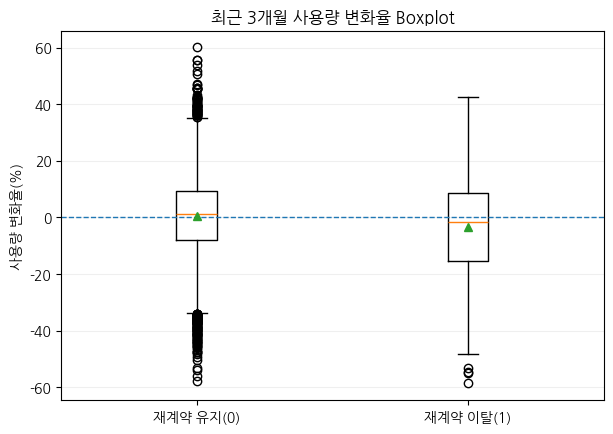

In [21]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-13. 최근 3개월 사용량 변화 Boxplot
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-13. 최근 3개월 사용량 변화 Boxplot
feature = "usage_change_3m"

group0 = df.loc[df[target]==0, feature].dropna() * 100
group1 = df.loc[df[target]==1, feature].dropna() * 100

plt.figure(figsize=(7, 4.8))
plt.boxplot([group0, group1], labels=["재계약 유지(0)", "재계약 이탈(1)"], showmeans=True)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("최근 3개월 사용량 변화율 Boxplot")
plt.ylabel("사용량 변화율(%)")
plt.grid(axis="y", alpha=0.2)
plt.show()


#### 코드 셀 22 — 팀원용 설명
### 이 셀은 무엇을 하나요?
사용량 변화를 `20% 이상 감소`, `5~20% 감소`, `±5%`, `증가` 등으로 나눠 각 구간의 이탈률을 계산합니다.

### 왜 필요한가요?
팀원이 “사용량이 어느 정도 줄어야 위험한가?”를 직관적으로 이해하는 데 도움이 됩니다.

### 그래프 읽는 법
가장 큰 감소 구간의 이탈률이 높은지 확인합니다.

,사용량_변화구간,고객수,이탈률(%)
0,20% 이상 감소,612,28.76%
1,5~20% 감소,"1,043",19.85%
2,±5% 이내,"1,435",14.70%
3,5~20% 증가,"1,332",16.67%
4,20% 이상 증가,484,17.36%


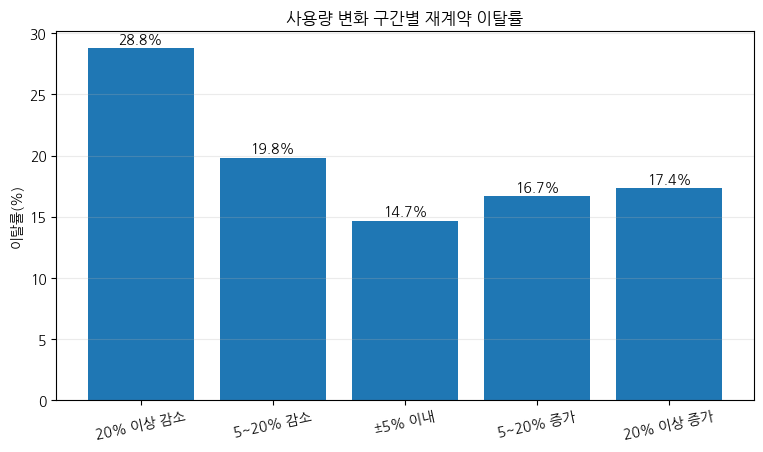

In [22]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-14. 사용량 변화 구간별 이탈률
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-14. 사용량 변화 구간별 이탈률
temp = df[["usage_change_3m", target]].dropna().copy()

bins = [-np.inf, -0.20, -0.05, 0.05, 0.20, np.inf]
labels = ["20% 이상 감소", "5~20% 감소", "±5% 이내", "5~20% 증가", "20% 이상 증가"]

temp["사용량_변화구간"] = pd.cut(temp["usage_change_3m"], bins=bins, labels=labels)

usage_bin = (
    temp.groupby("사용량_변화구간", observed=False)[target]
        .agg(고객수="count", 이탈률="mean")
        .reset_index()
)
usage_bin["이탈률(%)"] = usage_bin["이탈률"] * 100

display(usage_bin.drop(columns="이탈률").style.format({
    "고객수":"{:,.0f}",
    "이탈률(%)":"{:.2f}%"
}))

plt.figure(figsize=(9, 4.8))
bars = plt.bar(usage_bin["사용량_변화구간"].astype(str), usage_bin["이탈률(%)"])
plt.title("사용량 변화 구간별 재계약 이탈률")
plt.ylabel("이탈률(%)")
plt.xticks(rotation=12)
plt.grid(axis="y", alpha=0.25)
for b, v in zip(bars, usage_bin["이탈률(%)"]):
    plt.text(b.get_x()+b.get_width()/2, v+0.4, f"{v:.1f}%", ha="center")
plt.show()


#### 코드 셀 23 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비율과 사용량 변화율의 유지/이탈 집단 차이를 `Mann-Whitney U` 검정으로 확인합니다.

### 왜 이 검정을 사용하나요?
연속형 변수가 완벽한 정규분포라고 가정하지 않아도 두 집단의 분포 차이를 비교할 수 있기 때문입니다.

### 결과 읽는 법
p-value가 작으면 합성데이터 내부에서 유지/이탈 집단의 분포 차이가 뚜렷하다고 볼 수 있습니다.

In [23]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-15. 연속형 Feature ↔ Target 통계검정
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-15. 연속형 Feature ↔ Target 통계검정
# Mann-Whitney U: 정규분포를 강하게 가정하지 않고 두 집단의 분포 차이를 비교

num_test_rows = []

for feature in continuous_features:
    g0 = df.loc[df[target]==0, feature].dropna()
    g1 = df.loc[df[target]==1, feature].dropna()

    u, p = mannwhitneyu(g0, g1, alternative="two-sided")

    num_test_rows.append([
        ko_name[feature],
        g0.mean(),
        g1.mean(),
        g1.mean() - g0.mean(),
        u,
        p,
        "유의" if p < 0.05 else "유의하지 않음"
    ])

num_test = pd.DataFrame(
    num_test_rows,
    columns=[
        "Feature", "유지 평균", "이탈 평균", "평균 차이(이탈-유지)",
        "Mann-Whitney U", "p-value", "p<0.05 여부"
    ]
)

display(num_test.style.format({
    "유지 평균":"{:.4f}",
    "이탈 평균":"{:.4f}",
    "평균 차이(이탈-유지)":"{:.4f}",
    "Mann-Whitney U":"{:,.1f}",
    "p-value":"{:.4g}"
}))


,Feature,유지 평균,이탈 평균,평균 차이(이탈-유지),Mann-Whitney U,p-value,p<0.05 여부
0,클라우드 비용 낭비율,0.2836,0.3128,0.0292,"1,491,181.5",7.102e-16,유의
1,최근 3개월 사용량 변화율,0.0035,-0.0332,-0.0367,"1,998,590.5",3.365e-07,유의



## 교차 피벗테이블과 히트맵

한 개 Feature만 보는 것보다 **두 조건이 동시에 있을 때 이탈률이 어떻게 달라지는지** 보면 데이터 구조를 더 쉽게 이해할 수 있습니다.

아래에서는 특히 다음 관계를 확인합니다.

1. **업종 × 기업 규모**
2. **서비스 장애 × 고객지원 문제**
3. **비용 낭비 수준 × 예산 초과 여부**
4. **사용량 변화 × 고객지원 문제**


#### 코드 셀 24 — 팀원용 설명
### 이 셀은 무엇을 하나요?
앞으로 여러 교차분석 결과를 같은 형식의 **히트맵**으로 그릴 수 있도록 공통 함수를 만듭니다.

### 히트맵이란?
표 안의 숫자 크기를 색의 진하기로 보여주는 그래프입니다. 숫자가 많은 표를 빠르게 비교할 때 유용합니다.

### 결과
이 셀은 함수를 정의하는 준비 단계라서 그래프가 바로 나오지 않아도 정상입니다.

In [24]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 히트맵을 matplotlib만으로 그리는 함수
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 히트맵을 matplotlib만으로 그리는 함수
def draw_heatmap(pivot, title, percent=True, figsize=(9, 5)):
    data = pivot.values.astype(float)

    plt.figure(figsize=figsize)
    im = plt.imshow(data, aspect="auto")
    plt.colorbar(im, label="이탈률(%)" if percent else "값")

    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=30, ha="right")
    plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    plt.title(title)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data[i, j]):
                txt = f"{data[i,j]:.1f}%" if percent else f"{data[i,j]:.2f}"
                plt.text(j, i, txt, ha="center", va="center",
                         color="white" if data[i,j] > np.nanmean(data) else "black",
                         fontsize=9)

    plt.tight_layout()
    plt.show()


#### 코드 셀 25 — 팀원용 설명
### 이 셀은 무엇을 하나요?
업종과 기업 규모를 **동시에** 고려했을 때 이탈률이 어떻게 달라지는지 피벗테이블과 히트맵으로 보여줍니다.

### 왜 필요한가요?
업종만 보거나 규모만 보면 숨겨질 수 있는 조합 효과를 확인하기 위해서입니다.

### 읽는 법
행은 업종, 열은 기업 규모입니다. 각 칸의 %가 해당 조합의 이탈률입니다.

company_size,large_250_plus,mid_50_249,small_10_49
industry,,,
construction_real_estate,14.3%,15.4%,21.9%
education_public,nan%,13.3%,16.7%
finance_insurance,5.0%,5.4%,0.0%
healthcare,20.0%,13.5%,20.5%
it_software,27.3%,20.8%,20.9%
manufacturing,16.4%,18.8%,19.5%
professional_services,14.0%,12.8%,19.7%
transport_logistics,0.0%,9.2%,28.2%
wholesale_retail,11.1%,15.0%,23.1%


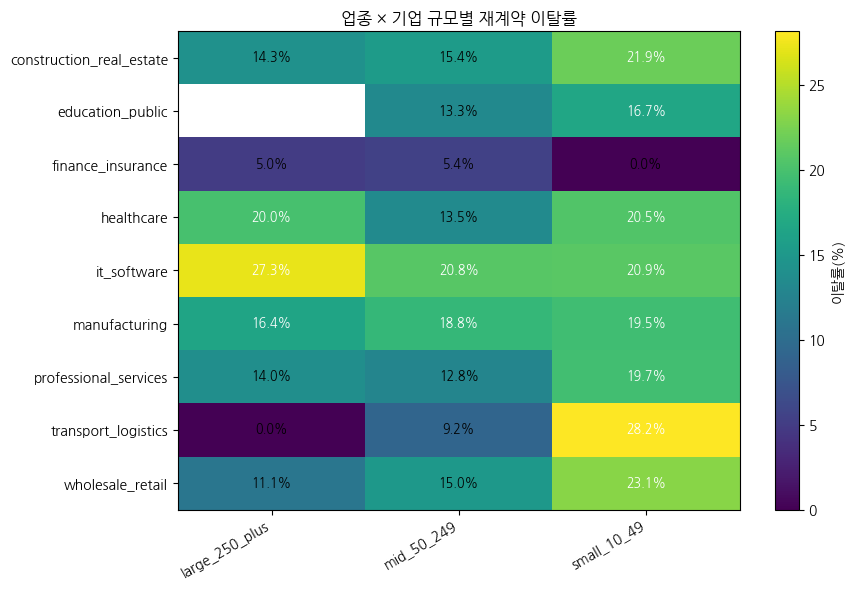

In [25]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-16. 업종 × 기업규모 이탈률 피벗테이블
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-16. 업종 × 기업규모 이탈률 피벗테이블
pivot_industry_size = pd.pivot_table(
    df,
    values=target,
    index="industry",
    columns="company_size",
    aggfunc="mean"
) * 100

display(pivot_industry_size.style.format("{:.1f}%"))
draw_heatmap(
    pivot_industry_size,
    "업종 × 기업 규모별 재계약 이탈률",
    figsize=(9, 6)
)


#### 코드 셀 26 — 팀원용 설명
### 이 셀은 무엇을 하나요?
서비스 장애와 고객지원 문제가 **동시에** 심할 때 이탈률이 얼마나 높아지는지 확인합니다.

### 왜 중요한가요?
장애가 발생해도 지원 대응이 좋으면 고객 불만이 완화될 수 있고, 반대로 장애와 지원 문제가 함께 심하면 위험이 더 커질 수 있습니다.

### 읽는 법
오른쪽·아래쪽의 높은 단계 조합에서 이탈률이 더 높아지는지 확인합니다.

,지원 0단계,지원 1단계,지원 2단계,지원 3단계
장애 0단계,9.1%,15.3%,22.4%,27.9%
장애 1단계,14.3%,19.2%,34.3%,39.6%
장애 2단계,23.1%,27.6%,49.6%,71.8%
장애 3단계,29.9%,34.6%,49.3%,65.7%


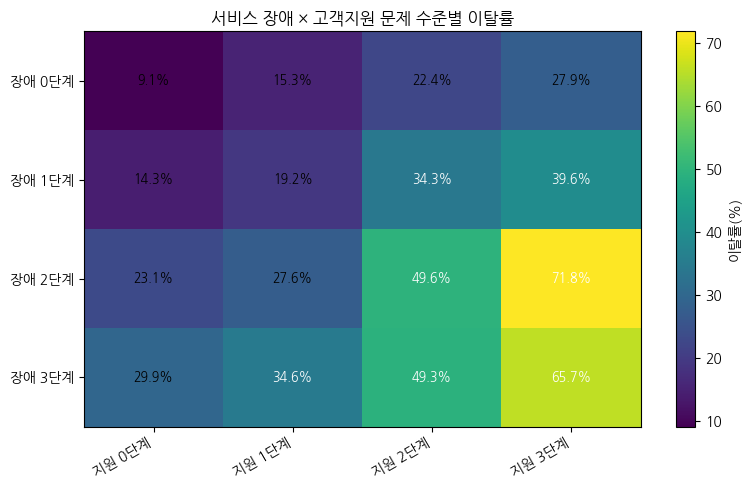

In [26]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-17. 장애 수준 × 고객지원 문제 수준 이탈률 피벗테이블
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-17. 장애 수준 × 고객지원 문제 수준 이탈률 피벗테이블
pivot_service_support = pd.pivot_table(
    df,
    values=target,
    index="service_disruption_level",
    columns="support_issue_level",
    aggfunc="mean"
) * 100

pivot_service_support.index = [f"장애 {int(x)}단계" for x in pivot_service_support.index]
pivot_service_support.columns = [f"지원 {int(x)}단계" for x in pivot_service_support.columns]

display(pivot_service_support.style.format("{:.1f}%"))
draw_heatmap(
    pivot_service_support,
    "서비스 장애 × 고객지원 문제 수준별 이탈률",
    figsize=(8, 5)
)


#### 코드 셀 27 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비 수준과 예산 초과 여부를 동시에 조합해 이탈률을 비교합니다.

### 왜 필요한가요?
두 변수 모두 비용 관련이지만 역할은 다릅니다.
- 비용 낭비율: 비효율의 **정도**
- 예산 초과: 실제 예산을 넘었는지에 대한 **결과**

둘이 같이 나쁠 때 위험이 더 커지는지 확인합니다.

예산상태,예산 정상,예산 초과
비용낭비_4분위,,
낮음(Q1),11.6%,23.9%
중하(Q2),14.7%,23.9%
중상(Q3),16.0%,25.6%
높음(Q4),20.1%,45.6%


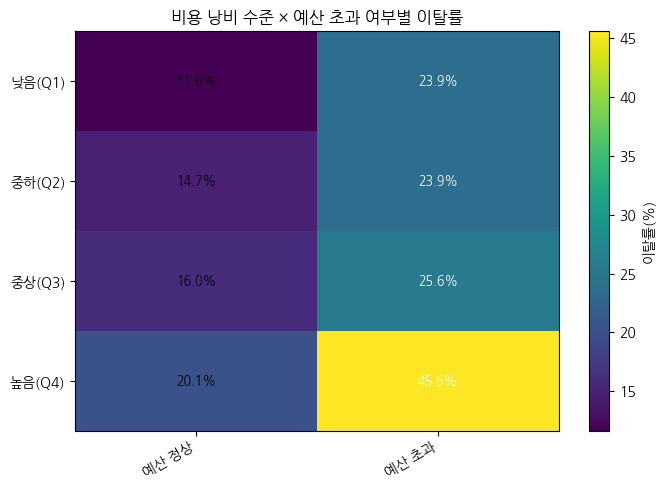

In [27]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-18. 비용 낭비 4분위 × 예산 초과 여부 이탈률
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-18. 비용 낭비 4분위 × 예산 초과 여부 이탈률
temp = df[["cloud_waste_ratio", "budget_overrun_flag", target]].dropna().copy()
temp["비용낭비_4분위"] = pd.qcut(
    temp["cloud_waste_ratio"],
    4,
    labels=["낮음(Q1)", "중하(Q2)", "중상(Q3)", "높음(Q4)"]
)
temp["예산상태"] = temp["budget_overrun_flag"].map({0.0:"예산 정상", 1.0:"예산 초과"})

pivot_waste_budget = pd.pivot_table(
    temp,
    values=target,
    index="비용낭비_4분위",
    columns="예산상태",
    aggfunc="mean",
    observed=False
) * 100

display(pivot_waste_budget.style.format("{:.1f}%"))
draw_heatmap(
    pivot_waste_budget,
    "비용 낭비 수준 × 예산 초과 여부별 이탈률",
    figsize=(7, 5)
)


#### 코드 셀 28 — 팀원용 설명
### 이 셀은 무엇을 하나요?
사용량 감소와 고객지원 문제를 함께 보면서 이탈률이 어떻게 달라지는지 확인합니다.

### 해석 예시
사용량이 크게 감소하면서 지원 문제도 심한 고객의 이탈률이 높다면, 서로 다른 위험 신호가 함께 나타날 때 위험이 커지는 구조를 확인할 수 있습니다.

지원수준,0단계,1단계,2단계,3단계
사용량_변화구간,,,,
20% 이상 감소,19.0%,30.0%,66.7%,82.1%
5~20% 감소,13.4%,20.5%,41.6%,54.2%
±5% 이내,9.6%,16.5%,30.1%,46.4%
5~20% 증가,10.8%,17.7%,29.9%,53.4%
20% 이상 증가,10.6%,24.8%,26.0%,56.5%


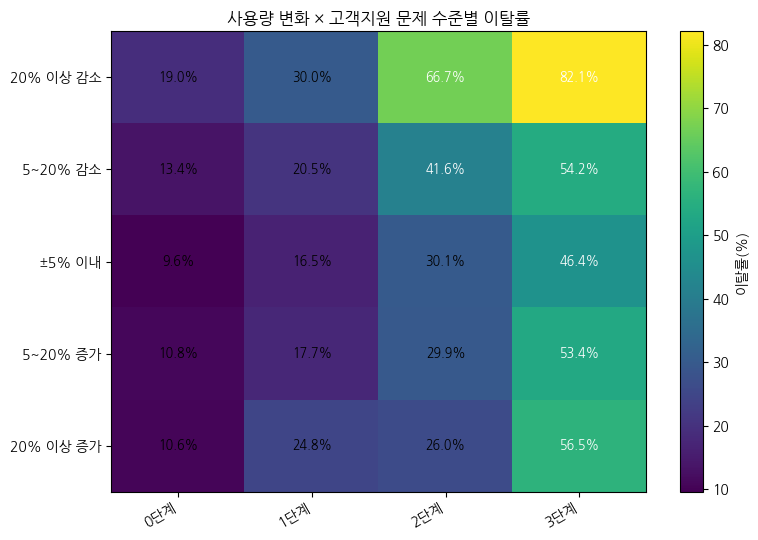

In [28]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 3-19. 사용량 변화 구간 × 고객지원 문제 수준 이탈률
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 3-19. 사용량 변화 구간 × 고객지원 문제 수준 이탈률
temp = df[["usage_change_3m", "support_issue_level", target]].dropna().copy()

temp["사용량_변화구간"] = pd.cut(
    temp["usage_change_3m"],
    bins=[-np.inf, -0.20, -0.05, 0.05, 0.20, np.inf],
    labels=["20% 이상 감소", "5~20% 감소", "±5% 이내", "5~20% 증가", "20% 이상 증가"]
)
temp["지원수준"] = temp["support_issue_level"].map({
    0.0:"0단계", 1.0:"1단계", 2.0:"2단계", 3.0:"3단계"
})

pivot_usage_support = pd.pivot_table(
    temp,
    values=target,
    index="사용량_변화구간",
    columns="지원수준",
    aggfunc="mean",
    observed=False
) * 100

display(pivot_usage_support.style.format("{:.1f}%"))
draw_heatmap(
    pivot_usage_support,
    "사용량 변화 × 고객지원 문제 수준별 이탈률",
    figsize=(8, 5.5)
)



# 4. Feature ↔ Feature 상관 · 중복 분석

이 단계에서는 다음 질문을 확인합니다.

> **“서로 너무 비슷한 정보를 가진 Feature가 있는가?”**

Feature끼리 어느 정도 관계가 있는 것은 자연스럽습니다.  
하지만 두 변수가 거의 같은 정보라면 모델이 불필요하게 복잡해질 수 있습니다.

여기서는 변수 종류에 맞게 다음 방법을 사용합니다.

- 숫자형·순서형끼리 → **Spearman 상관계수**
- 범주형끼리 → **Cramer's V**
- 여러 변수를 동시에 고려 → **VIF(다중공선성 점검)**
- 완전히 같은 행·고객ID → **중복 검사**


#### 코드 셀 29 — 팀원용 설명
### 이 셀은 무엇을 하나요?
숫자형·순서형 Feature끼리 얼마나 비슷하게 움직이는지 `Spearman 상관계수`로 계산합니다.

### 상관계수를 쉽게 읽는 법
- +1에 가까움: 같이 증가하는 경향이 강함
- 0에 가까움: 뚜렷한 관계가 약함
- -1에 가까움: 한쪽이 증가할 때 다른 쪽은 감소하는 경향이 강함

### 목적
두 Feature가 사실상 같은 정보를 반복하고 있는지 확인합니다.

In [29]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-1. 숫자형/순서형 Feature의 Spearman 상관계수
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-1. 숫자형/순서형 Feature의 Spearman 상관계수
numeric_for_corr = [
    "budget_overrun_flag",
    "cloud_waste_ratio",
    "usage_change_3m",
    "service_disruption_level",
    "support_issue_level"
]

spearman_corr = df[numeric_for_corr].corr(method="spearman")
display(spearman_corr.style.format("{:.3f}"))


,budget_overrun_flag,cloud_waste_ratio,usage_change_3m,service_disruption_level,support_issue_level
budget_overrun_flag,1.000,0.091,-0.011,0.005,0.021
cloud_waste_ratio,0.091,1.000,-0.001,-0.002,0.015
usage_change_3m,-0.011,-0.001,1.000,0.002,0.007
service_disruption_level,0.005,-0.002,0.002,1.000,0.336
support_issue_level,0.021,0.015,0.007,0.336,1.000


#### 코드 셀 30 — 팀원용 설명
### 이 셀은 무엇을 하나요?
앞에서 계산한 상관계수를 색으로 보여줍니다.

### 그래프 읽는 법
대각선은 자기 자신과의 상관이라 항상 1입니다. 우리가 볼 것은 대각선 바깥 값입니다. 절대값이 0.7 이상인 칸이 많다면 중복 가능성을 더 자세히 확인해야 합니다.

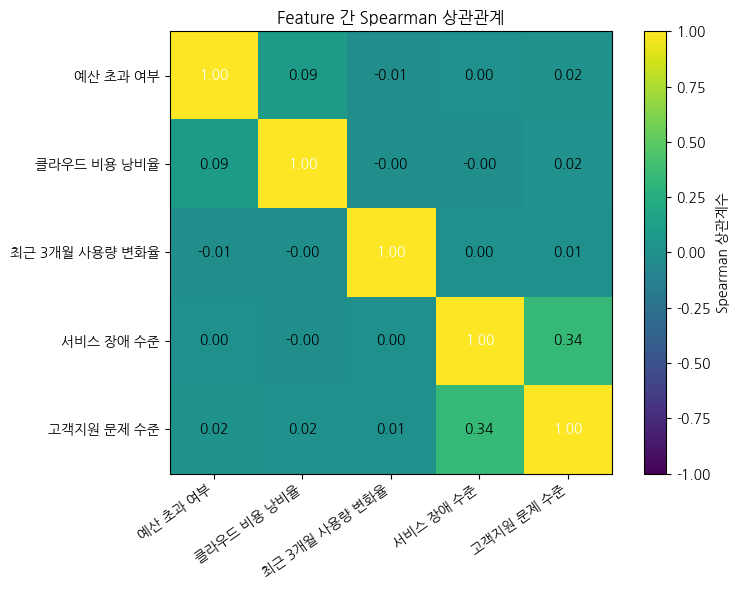

In [30]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-2. Spearman 상관관계 히트맵
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-2. Spearman 상관관계 히트맵
corr = spearman_corr
data = corr.values

plt.figure(figsize=(8, 6))
im = plt.imshow(data, vmin=-1, vmax=1)
plt.colorbar(im, label="Spearman 상관계수")

labels = [ko_name[c] for c in corr.columns]
plt.xticks(range(len(labels)), labels, rotation=35, ha="right")
plt.yticks(range(len(labels)), labels)
plt.title("Feature 간 Spearman 상관관계")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(data[i,j]) > 0.5 else "black")

plt.tight_layout()
plt.show()


#### 코드 셀 31 — 팀원용 설명
### 이 셀은 무엇을 하나요?
절대 상관계수가 **0.70 이상인 Feature 쌍**을 자동으로 찾아줍니다.

### 왜 필요한가요?
히트맵을 눈으로만 확인하면 놓칠 수 있기 때문에 자동 점검을 추가한 것입니다.

### 결과
아무 것도 발견되지 않으면 숫자형 Feature 사이에 매우 강한 중복은 없다고 볼 수 있습니다.

In [31]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-3. 높은 상관관계 후보 자동 탐색
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-3. 높은 상관관계 후보 자동 탐색
high_corr_pairs = []

for i in range(len(spearman_corr.columns)):
    for j in range(i+1, len(spearman_corr.columns)):
        a = spearman_corr.columns[i]
        b = spearman_corr.columns[j]
        value = spearman_corr.iloc[i, j]

        if abs(value) >= 0.70:
            high_corr_pairs.append([ko_name[a], ko_name[b], value])

if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs, columns=["Feature A", "Feature B", "상관계수"]))
else:
    print("절대 상관계수 0.70 이상인 Feature 쌍은 없습니다.")
    print("→ 숫자형/순서형 Feature 중 '거의 같은 정보'를 가진 변수는 현재 기준에서 발견되지 않았습니다.")


절대 상관계수 0.70 이상인 Feature 쌍은 없습니다.
→ 숫자형/순서형 Feature 중 '거의 같은 정보'를 가진 변수는 현재 기준에서 발견되지 않았습니다.


#### 코드 셀 32 — 팀원용 설명
### 이 셀은 무엇을 하나요?
범주형 변수끼리의 관계 강도를 `Cramer's V`로 계산합니다.

### 왜 Spearman과 다른 방법을 쓰나요?
업종처럼 숫자의 크고 작음이 없는 범주는 일반 상관계수보다 범주형 전용 관계 지표가 더 적절합니다.

### 읽는 법
0에 가까울수록 관계가 약하고 1에 가까울수록 강합니다.

In [32]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-4. 범주형 Feature 간 Cramer's V 행렬
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-4. 범주형 Feature 간 Cramer's V 행렬
cat_for_assoc = [
    "industry",
    "company_size",
    "budget_overrun_flag",
    "service_disruption_level",
    "support_issue_level"
]

cv_matrix = pd.DataFrame(
    np.eye(len(cat_for_assoc)),
    index=cat_for_assoc,
    columns=cat_for_assoc,
    dtype=float
)

for i, a in enumerate(cat_for_assoc):
    for j, b in enumerate(cat_for_assoc):
        if i == j:
            continue
        sub = df[[a, b]].dropna()
        cv_matrix.loc[a, b] = cramers_v(sub[a], sub[b])

cv_display = cv_matrix.rename(index=ko_name, columns=ko_name)
display(cv_display.style.format("{:.3f}"))


,업종,기업 규모,예산 초과 여부,서비스 장애 수준,고객지원 문제 수준
업종,1.000,0.163,0.060,0.027,0.022
기업 규모,0.163,1.000,0.074,0.025,0.000
예산 초과 여부,0.060,0.074,1.000,0.000,0.000
서비스 장애 수준,0.027,0.025,0.000,1.000,0.222
고객지원 문제 수준,0.022,0.000,0.000,0.222,1.000


#### 코드 셀 33 — 팀원용 설명
### 이 셀은 무엇을 하나요?
범주형 변수끼리의 관계를 색으로 보여줍니다.

### 왜 필요한가요?
예를 들어 업종과 기업 규모가 너무 강하게 묶여 있다면 두 변수가 비슷한 정보를 전달할 가능성이 있습니다. 히트맵으로 이런 패턴을 빠르게 확인합니다.

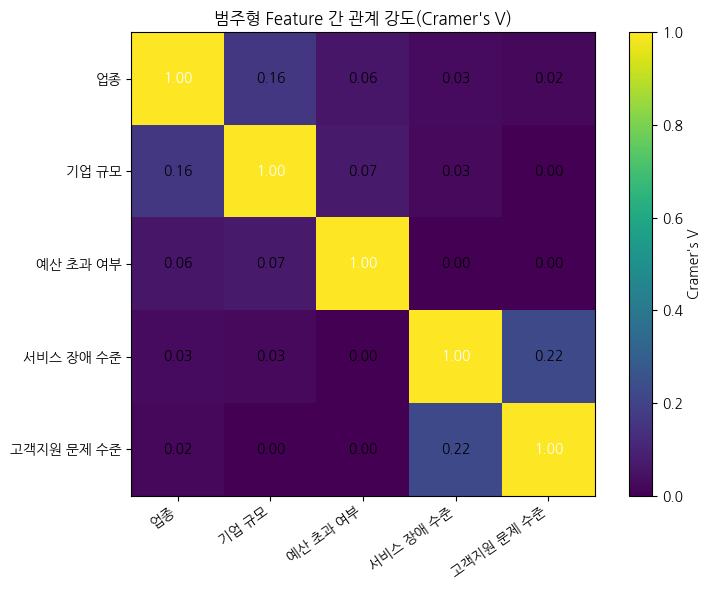

In [33]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-5. Cramer's V 히트맵
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-5. Cramer's V 히트맵
data = cv_display.values

plt.figure(figsize=(8, 6))
im = plt.imshow(data, vmin=0, vmax=1)
plt.colorbar(im, label="Cramer's V")

labels = list(cv_display.columns)
plt.xticks(range(len(labels)), labels, rotation=35, ha="right")
plt.yticks(range(len(labels)), labels)
plt.title("범주형 Feature 간 관계 강도(Cramer's V)")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i,j]:.2f}", ha="center", va="center",
                 color="white" if data[i,j] > 0.5 else "black")

plt.tight_layout()
plt.show()


#### 코드 셀 34 — 팀원용 설명
### 이 셀은 무엇을 하나요?
여러 Feature를 동시에 고려했을 때 어떤 변수가 다른 변수들의 조합으로 지나치게 잘 설명되는지 **VIF**로 확인합니다.

### VIF를 쉽게 읽는 법
- 약 1: 중복이 거의 없음
- 5 이상: 주의해서 확인
- 10 이상: 강한 다중공선성 의심

### 주의
VIF가 조금 높다고 바로 삭제하는 것이 아니라 업무적 의미와 함께 판단합니다.

In [34]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-6. VIF(다중공선성) 계산
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-6. VIF(다중공선성) 계산
# VIF가 높으면 다른 Feature 조합으로 해당 변수를 지나치게 잘 설명할 수 있다는 뜻입니다.
# 일반적으로 5 이상이면 주의, 10 이상이면 강한 다중공선성을 의심합니다.

X = df[
    [
        "industry", "company_size",
        "budget_overrun_flag", "cloud_waste_ratio", "usage_change_3m",
        "service_disruption_level", "support_issue_level"
    ]
].copy()

# 숫자형 결측치는 중앙값으로 채움
for c in [
    "budget_overrun_flag", "cloud_waste_ratio", "usage_change_3m",
    "service_disruption_level", "support_issue_level"
]:
    X[c] = X[c].fillna(X[c].median())

# 범주형 결측치는 'MISSING'으로 처리 후 더미변수화
for c in ["industry", "company_size"]:
    X[c] = X[c].fillna("MISSING")

X_encoded = pd.get_dummies(X, columns=["industry", "company_size"], drop_first=True, dtype=float)

def calculate_vif(data):
    result = []
    values = data.astype(float)

    for col in values.columns:
        y = values[col].values
        X_other = values.drop(columns=col).values

        model = LinearRegression()
        model.fit(X_other, y)
        r2 = model.score(X_other, y)

        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        result.append([col, vif])

    return pd.DataFrame(result, columns=["변수", "VIF"]).sort_values("VIF", ascending=False)

vif_table = calculate_vif(X_encoded)
display(vif_table.style.format({"VIF":"{:.2f}"}))


,변수,VIF
14,company_size_small_10_49,3.44
13,company_size_mid_50_249,3.29
9,industry_manufacturing,1.99
10,industry_professional_services,1.67
12,industry_wholesale_retail,1.54
7,industry_healthcare,1.34
8,industry_it_software,1.33
11,industry_transport_logistics,1.19
3,service_disruption_level,1.16
4,support_issue_level,1.16


#### 코드 셀 35 — 팀원용 설명
### 이 셀은 무엇을 하나요?
각 변수의 VIF를 막대그래프로 보여주고, 참고 기준선 5와 10을 표시합니다.

### 그래프 읽는 법
막대가 5 아래에 있으면 일반적으로 큰 문제는 없다고 볼 수 있습니다. 5 이상이면 왜 높은지 추가 검토합니다.

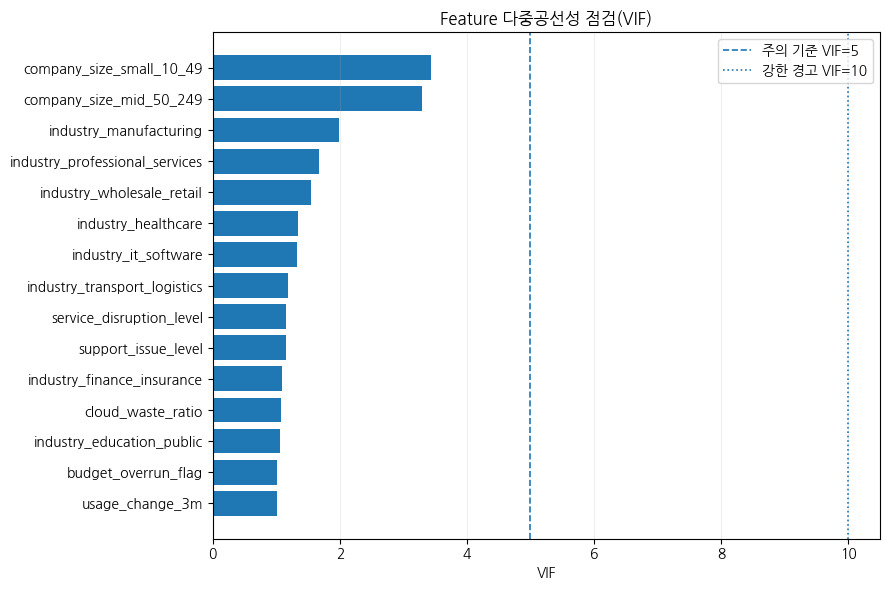

In [35]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-7. VIF 시각화
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-7. VIF 시각화
plot_vif = vif_table.replace([np.inf], np.nan).dropna().sort_values("VIF", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_vif["변수"], plot_vif["VIF"])
plt.axvline(5, linestyle="--", linewidth=1.2, label="주의 기준 VIF=5")
plt.axvline(10, linestyle=":", linewidth=1.2, label="강한 경고 VIF=10")
plt.title("Feature 다중공선성 점검(VIF)")
plt.xlabel("VIF")
plt.legend()
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


#### 코드 셀 36 — 팀원용 설명
### 이 셀은 무엇을 하나요?
`customer_id`가 중복되었는지, 또는 ID를 제외한 모든 Feature와 Target 값이 완전히 같은 행이 있는지 확인합니다.

### 왜 필요한가요?
같은 고객이 실수로 여러 번 들어가면 분석 결과가 왜곡될 수 있기 때문입니다.

### 주의
ID가 다르지만 값이 우연히 같은 두 고객은 실제로 존재할 수 있으므로 무조건 삭제하면 안 됩니다.

In [36]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-8. 완전 중복 데이터 확인
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-8. 완전 중복 데이터 확인
customer_id_dup = df["customer_id"].duplicated().sum()
feature_dup = df.drop(columns=["customer_id"]).duplicated().sum()

dup_table = pd.DataFrame({
    "검사항목": [
        "customer_id 중복",
        "customer_id를 제외한 모든 Feature+Target 완전 동일 행"
    ],
    "중복 개수": [customer_id_dup, feature_dup]
})

display(dup_table)

print("주의:")
print("- customer_id 중복은 실제로 동일 고객이 두 번 들어간 문제일 수 있으므로 0개가 바람직합니다.")
print("- Feature 값이 우연히 완전히 같은 서로 다른 고객은 존재할 수 있으므로, ID가 다르면 무조건 삭제하면 안 됩니다.")


,검사항목,중복 개수
0,customer_id 중복,0
1,customer_id를 제외한 모든 Feature+Target 완전 동일 행,14


주의:
- customer_id 중복은 실제로 동일 고객이 두 번 들어간 문제일 수 있으므로 0개가 바람직합니다.
- Feature 값이 우연히 완전히 같은 서로 다른 고객은 존재할 수 있으므로, ID가 다르면 무조건 삭제하면 안 됩니다.


#### 코드 셀 37 — 팀원용 설명
### 이 셀은 무엇을 하나요?
앞에서 계산한 Target 관련성, Feature 간 상관, 업무적 의미를 합쳐 **각 Feature를 유지할지 제거할지** 표로 정리합니다.

### 왜 중요한가요?
“상관계수가 높아서 삭제”처럼 기계적으로 결정하지 않고, **통계 결과 + 업무 의미**를 함께 근거로 기록하기 위해서입니다.

### 결과
현재 설계에서는 7개 주요 Feature 모두 서로 다른 의미를 가지므로 유지하는 방향을 제안합니다.

In [37]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 4-9. Feature 유지/제거 판단을 위한 근거 요약
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 4-9. Feature 유지/제거 판단을 위한 근거 요약

# Target 관련성 값 가져오기
cat_v_map = dict(zip(cat_test["Feature"], cat_test["Cramer's V"]))
cat_p_map = dict(zip(cat_test["Feature"], cat_test["p-value"]))
num_p_map = dict(zip(num_test["Feature"], num_test["p-value"]))

# 주요 Feature 간 실제 상관
budget_waste_corr = spearman_corr.loc["budget_overrun_flag", "cloud_waste_ratio"]
service_support_corr = spearman_corr.loc["service_disruption_level", "support_issue_level"]

decision_rows = [
    [
        "업종",
        f"Target 관계: Cramer's V={cat_v_map['업종']:.3f}, p={cat_p_map['업종']:.4g}",
        "다른 Feature와 강한 중복 없음",
        "유지",
        "Target 효과는 크지 않지만 업종 자체가 독립적인 고객 특성이며 세그먼트 분석에 필요"
    ],
    [
        "기업 규모",
        f"Target 관계: Cramer's V={cat_v_map['기업 규모']:.3f}, p={cat_p_map['기업 규모']:.4g}",
        "업종과 일부 관련은 있으나 강하지 않음",
        "유지",
        "기업 규모별 이탈률 차이가 있고 실제 서비스 운영에서도 중요한 기본 고객 특성"
    ],
    [
        "예산 초과 여부",
        f"Target 관계: Cramer's V={cat_v_map['예산 초과 여부']:.3f}, p={cat_p_map['예산 초과 여부']:.4g}",
        f"비용 낭비율과 Spearman={budget_waste_corr:.3f}",
        "유지",
        "비용 낭비율과 의미가 다르고 실제 상관도 낮아 중복 Feature로 보기 어려움"
    ],
    [
        "클라우드 비용 낭비율",
        f"유지/이탈 분포 차이 p={num_p_map['클라우드 비용 낭비율']:.4g}",
        f"예산 초과와 Spearman={budget_waste_corr:.3f}",
        "유지",
        "연속형 비용 효율 정보를 제공하므로 예산 초과 0/1보다 세밀한 정보가 있음"
    ],
    [
        "최근 3개월 사용량 변화율",
        f"유지/이탈 분포 차이 p={num_p_map['최근 3개월 사용량 변화율']:.4g}",
        "다른 주요 Feature와 강한 상관 없음",
        "유지",
        "비용·장애·지원과 다른 고객 사용행동 정보를 제공"
    ],
    [
        "서비스 장애 수준",
        f"Target 관계: Cramer's V={cat_v_map['서비스 장애 수준']:.3f}, p={cat_p_map['서비스 장애 수준']:.4g}",
        f"고객지원 문제와 Spearman={service_support_corr:.3f}",
        "유지",
        "지원 문제와 일부 연관되지만 서비스 품질 자체를 나타내는 별도 정보"
    ],
    [
        "고객지원 문제 수준",
        f"Target 관계: Cramer's V={cat_v_map['고객지원 문제 수준']:.3f}, p={cat_p_map['고객지원 문제 수준']:.4g}",
        f"서비스 장애와 Spearman={service_support_corr:.3f}",
        "유지",
        "장애와 일부 연관되지만 고객 경험·대응 품질을 나타내는 별도 정보"
    ]
]

decision_table = pd.DataFrame(
    decision_rows,
    columns=["Feature", "Target 관련성", "중복 점검", "판단", "판단 이유"]
)

display(decision_table)


,Feature,Target 관련성,중복 점검,판단,판단 이유
0,업종,"Target 관계: Cramer's V=0.052, p=0.006107",다른 Feature와 강한 중복 없음,유지,Target 효과는 크지 않지만 업종 자체가 독립적인 고객 특성이며 세그먼트 분석에 필요
1,기업 규모,"Target 관계: Cramer's V=0.064, p=1.245e-05",업종과 일부 관련은 있으나 강하지 않음,유지,기업 규모별 이탈률 차이가 있고 실제 서비스 운영에서도 중요한 기본 고객 특성
2,예산 초과 여부,"Target 관계: Cramer's V=0.156, p=5.355e-28",비용 낭비율과 Spearman=0.091,유지,비용 낭비율과 의미가 다르고 실제 상관도 낮아 중복 Feature로 보기 어려움
3,클라우드 비용 낭비율,유지/이탈 분포 차이 p=7.102e-16,예산 초과와 Spearman=0.091,유지,연속형 비용 효율 정보를 제공하므로 예산 초과 0/1보다 세밀한 정보가 있음
4,최근 3개월 사용량 변화율,유지/이탈 분포 차이 p=3.365e-07,다른 주요 Feature와 강한 상관 없음,유지,비용·장애·지원과 다른 고객 사용행동 정보를 제공
5,서비스 장애 수준,"Target 관계: Cramer's V=0.264, p=1.168e-74",고객지원 문제와 Spearman=0.336,유지,지원 문제와 일부 연관되지만 서비스 품질 자체를 나타내는 별도 정보
6,고객지원 문제 수준,"Target 관계: Cramer's V=0.287, p=3.948e-88",서비스 장애와 Spearman=0.336,유지,장애와 일부 연관되지만 고객 경험·대응 품질을 나타내는 별도 정보



# 5. 결측치 · 이상치 · 중복 처리 기준 확정

이 단계는 EDA에서 발견한 문제를 실제 모델링 전에 **어떻게 처리할지 원칙을 확정하는 단계**입니다.

핵심 질문은 세 가지입니다.

1. **결측치**: 값이 비어 있는 고객을 삭제할 것인가, 채울 것인가?
2. **이상치**: 극단적인 값을 오류로 볼 것인가, 중요한 고객 신호로 볼 것인가?
3. **중복**: 같은 고객/같은 행이 있다면 삭제해야 하는가?

> 이 프로젝트에서는 합성데이터를 만들 때 일부 결측치를 의도적으로 넣었습니다.  
> 따라서 결측값이 있다고 해서 곧바로 “데이터 오류”로 간주하면 안 됩니다.


#### 코드 셀 38 — 팀원용 설명
### 이 셀은 무엇을 하나요?
각 변수의 결측치 개수와 비율, 그리고 **결측치가 하나라도 있는 고객 수**를 계산합니다.

### 왜 필요한가요?
결측률이 높으면 행 삭제보다 대치가 필요할 수 있고, 반대로 결측이 거의 없다면 처리 방식이 단순해집니다.

### 읽는 법
결측률이 몇 %인지 보고, 전체 고객 중 결측이 있는 고객이 얼마나 되는지 확인합니다.

In [38]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-1. 전체 결측치 현황
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-1. 전체 결측치 현황
missing_table = pd.DataFrame({
    "결측 개수": df.isna().sum(),
    "결측률(%)": (df.isna().mean() * 100)
}).sort_values("결측률(%)", ascending=False)

display(missing_table.style.format({
    "결측 개수":"{:,.0f}",
    "결측률(%)":"{:.2f}%"
}))

print(f"전체 고객 수: {len(df):,}명")
print(f"결측치가 하나라도 있는 고객 수: {df.isna().any(axis=1).sum():,}명")
print(f"결측치가 하나라도 있는 고객 비율: {df.isna().any(axis=1).mean()*100:.2f}%")


,결측 개수,결측률(%)
usage_change_3m,94,1.88%
service_disruption_level,93,1.86%
cloud_waste_ratio,91,1.82%
budget_overrun_flag,79,1.58%
support_issue_level,72,1.44%
customer_id,0,0.00%
company_size,0,0.00%
industry,0,0.00%
renewal_churn,0,0.00%


전체 고객 수: 5,000명
결측치가 하나라도 있는 고객 수: 222명
결측치가 하나라도 있는 고객 비율: 4.44%


#### 코드 셀 39 — 팀원용 설명
### 이 셀은 무엇을 하나요?
각 Feature의 결측률을 가로 막대그래프로 보여줍니다.

### 왜 필요한가요?
어느 Feature에서 값이 가장 자주 비는지 한눈에 확인할 수 있습니다.

### 그래프 읽는 법
막대가 길수록 결측률이 높은 Feature입니다.

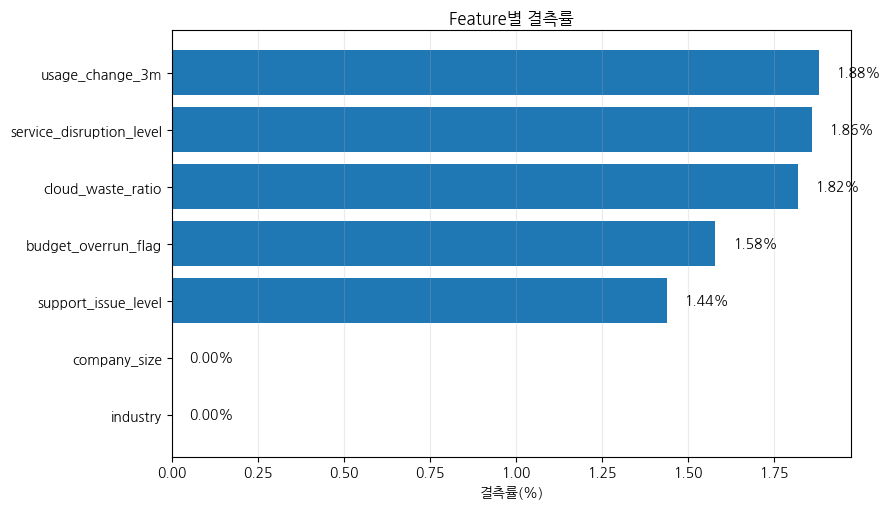

In [39]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-2. Feature별 결측률 그래프
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-2. Feature별 결측률 그래프
feature_missing = (
    (df.isna().mean() * 100)
    .drop(labels=["customer_id", "renewal_churn"], errors="ignore")
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5.2))
bars = plt.barh(feature_missing.index, feature_missing.values)
plt.title("Feature별 결측률")
plt.xlabel("결측률(%)")
plt.grid(axis="x", alpha=0.25)

for b, v in zip(bars, feature_missing.values):
    plt.text(v + 0.05, b.get_y()+b.get_height()/2, f"{v:.2f}%", va="center")

plt.tight_layout()
plt.show()


#### 코드 셀 40 — 팀원용 설명
### 이 셀은 무엇을 하나요?
고객 한 명당 결측치가 0개인지, 1개인지, 2개 이상인지 분포를 확인합니다.

### 왜 필요한가요?
한두 개만 비는 경우와 여러 시스템 데이터가 한꺼번에 비는 경우는 처리 관점이 다를 수 있기 때문입니다.

### 그래프 읽는 법
0개 막대가 가장 크고, 2개 이상 결측 고객이 소수라면 전체 데이터 품질은 비교적 양호하다고 볼 수 있습니다.

,한 고객의 결측 개수,고객 수,비율(%)
0,0,"4,778",95.56%
1,1,100,2.00%
2,2,93,1.86%
3,3,1,0.02%
4,5,28,0.56%


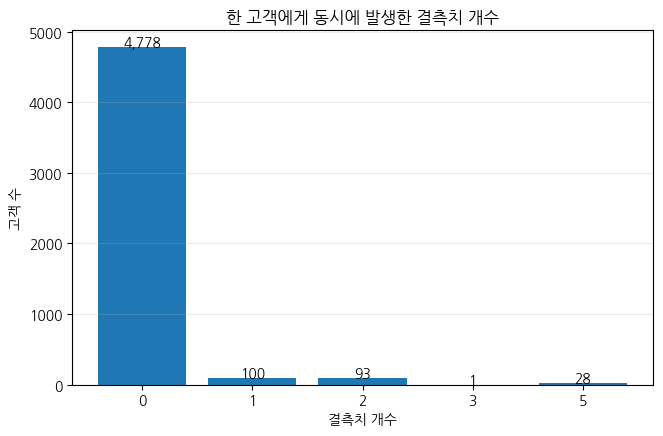

In [40]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-3. 결측 개수 패턴: 한 고객에게 몇 개의 값이 동시에 비어 있는가?
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-3. 결측 개수 패턴: 한 고객에게 몇 개의 값이 동시에 비어 있는가?
missing_count_per_row = df.isna().sum(axis=1)

missing_pattern_count = (
    missing_count_per_row.value_counts()
    .sort_index()
    .rename_axis("한 고객의 결측 개수")
    .reset_index(name="고객 수")
)
missing_pattern_count["비율(%)"] = missing_pattern_count["고객 수"] / len(df) * 100

display(missing_pattern_count.style.format({
    "고객 수":"{:,.0f}",
    "비율(%)":"{:.2f}%"
}))

plt.figure(figsize=(7.5, 4.6))
bars = plt.bar(
    missing_pattern_count["한 고객의 결측 개수"].astype(str),
    missing_pattern_count["고객 수"]
)
plt.title("한 고객에게 동시에 발생한 결측치 개수")
plt.xlabel("결측치 개수")
plt.ylabel("고객 수")
plt.grid(axis="y", alpha=0.25)

for b, v in zip(bars, missing_pattern_count["고객 수"]):
    plt.text(b.get_x()+b.get_width()/2, v+10, f"{v:,}", ha="center")

plt.show()


#### 코드 셀 41 — 팀원용 설명
### 이 셀은 무엇을 하나요?
어떤 Feature들이 같은 고객에서 **동시에 결측되는지** 행렬과 히트맵으로 확인합니다.

### 왜 필요한가요?
이 프로젝트는 비용관리 시스템, 모니터링 시스템 등 특정 데이터 원천의 문제로 여러 Feature가 함께 비는 구조를 일부러 반영했습니다.

### 읽는 법
숫자가 큰 칸은 두 Feature가 동시에 비는 고객이 많다는 뜻입니다.

,budget_overrun_flag,cloud_waste_ratio,usage_change_3m,service_disruption_level,support_issue_level
budget_overrun_flag,79,68,28,28,28
cloud_waste_ratio,68,91,28,28,28
usage_change_3m,28,28,94,82,29
service_disruption_level,28,28,82,93,29
support_issue_level,28,28,29,29,72


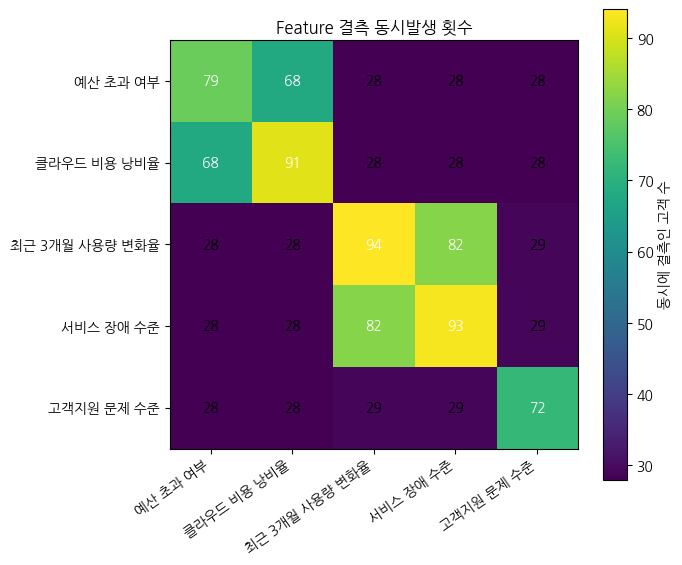

In [41]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-4. 어떤 Feature들이 같이 비는가? 결측 동시발생 행렬
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-4. 어떤 Feature들이 같이 비는가? 결측 동시발생 행렬
operational_features = [
    "budget_overrun_flag",
    "cloud_waste_ratio",
    "usage_change_3m",
    "service_disruption_level",
    "support_issue_level"
]

missing_bool = df[operational_features].isna().astype(int)
missing_cooccurrence = missing_bool.T.dot(missing_bool)

display(missing_cooccurrence)

plt.figure(figsize=(7, 6))
data = missing_cooccurrence.values
im = plt.imshow(data)
plt.colorbar(im, label="동시에 결측인 고객 수")
plt.xticks(range(len(operational_features)),
           [ko_name[c] for c in operational_features],
           rotation=35, ha="right")
plt.yticks(range(len(operational_features)),
           [ko_name[c] for c in operational_features])
plt.title("Feature 결측 동시발생 횟수")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{int(data[i,j])}", ha="center", va="center",
                 color="white" if data[i,j] > data.mean() else "black")

plt.tight_layout()
plt.show()


#### 코드 셀 42 — 팀원용 설명
### 이 셀은 무엇을 하나요?
특정 Feature가 비어 있는 고객과 값이 있는 고객의 이탈률을 비교합니다.

### 왜 필요한가요?
결측 자체가 위험 신호일 수도 있기 때문입니다. 예를 들어 관리 체계가 약한 고객에서 데이터 누락과 이탈이 함께 나타날 수 있습니다.

### 결과 활용
차이가 크다면 향후 모델에서 `이 값이 원래 비어 있었는가?`를 나타내는 **결측 표시 변수**를 추가하는 것을 검토할 수 있습니다.

In [42]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-5. 결측 여부에 따라 이탈률이 다른지 확인
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-5. 결측 여부에 따라 이탈률이 다른지 확인
# 결측 여부 자체가 Target과 강하게 연결되어 있으면,
# 단순 대치 전에 missing indicator를 추가하는 것이 도움이 될 수 있습니다.

missing_target_rows = []

for feature in operational_features:
    miss = df[feature].isna()
    if miss.sum() == 0:
        continue

    missing_churn = df.loc[miss, target].mean()
    observed_churn = df.loc[~miss, target].mean()

    missing_target_rows.append([
        ko_name[feature],
        miss.sum(),
        missing_churn * 100,
        observed_churn * 100,
        (missing_churn - observed_churn) * 100
    ])

missing_target_table = pd.DataFrame(
    missing_target_rows,
    columns=[
        "Feature", "결측 고객 수", "결측 고객 이탈률(%)",
        "비결측 고객 이탈률(%)", "차이(%p)"
    ]
)

display(missing_target_table.style.format({
    "결측 고객 수":"{:,.0f}",
    "결측 고객 이탈률(%)":"{:.2f}%",
    "비결측 고객 이탈률(%)":"{:.2f}%",
    "차이(%p)":"{:+.2f}"
}))


,Feature,결측 고객 수,결측 고객 이탈률(%),비결측 고객 이탈률(%),차이(%p)
0,예산 초과 여부,79,18.99%,18.27%,+0.72
1,클라우드 비용 낭비율,91,17.58%,18.29%,-0.71
2,최근 3개월 사용량 변화율,94,14.89%,18.34%,-3.45
3,서비스 장애 수준,93,11.83%,18.40%,-6.57
4,고객지원 문제 수준,72,6.94%,18.45%,-11.50



## 결측치 처리 원칙

이 프로젝트에서는 **행 삭제보다 대치(imputation)** 를 기본 원칙으로 두는 것이 적절합니다.

이유는 간단합니다.

- 결측 비율이 크지 않음
- 결측은 데이터 수집 시스템의 공백을 표현하도록 의도적으로 생성됨
- 결측 고객을 모두 삭제하면 실제로는 중요한 고객까지 사라질 수 있음
- 모델 운영 상황에서는 “값이 없는 고객도 예측”해야 함

따라서 권장 방식은 다음과 같습니다.

- 연속형(`cloud_waste_ratio`, `usage_change_3m`) → **Train 데이터의 중앙값**
- 0/1 또는 순서형(`budget_overrun_flag`, `service_disruption_level`, `support_issue_level`) → **Train 데이터의 최빈값**
- 필요 시 각 Feature별 **결측 여부 표시 변수(missing indicator)** 추가
- **반드시 Train/Test 분리 후 Train에서 계산한 값으로 Test를 처리**


#### 코드 셀 43 — 팀원용 설명
### 이 셀은 무엇을 하나요?
각 Feature의 결측치를 어떤 방식으로 채울지 권장 기준을 표로 정리합니다.

### 핵심 원칙
- 연속형: 중앙값
- 0/1 또는 순서형: 최빈값
- 필요 시 결측 여부 표시 변수 추가

### 매우 중요
중앙값·최빈값은 **전체 데이터가 아니라 Train 데이터에서만 계산**해야 합니다. 그래야 Test 정보가 미리 들어가는 데이터 누수를 막을 수 있습니다.

In [43]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-6. Train 기준으로 사용할 권장 결측 처리 방식 정리
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-6. Train 기준으로 사용할 권장 결측 처리 방식 정리
missing_policy = pd.DataFrame([
    ["budget_overrun_flag", "예산 초과 여부", "최빈값 대치 + 필요 시 결측표시 변수", "0/1 범주형"],
    ["cloud_waste_ratio", "클라우드 비용 낭비율", "중앙값 대치 + 필요 시 결측표시 변수", "연속형이며 극단값의 영향 완화"],
    ["usage_change_3m", "최근 3개월 사용량 변화율", "중앙값 대치 + 필요 시 결측표시 변수", "연속형이며 극단값의 영향 완화"],
    ["service_disruption_level", "서비스 장애 수준", "최빈값 대치 + 필요 시 결측표시 변수", "0~3 순서형"],
    ["support_issue_level", "고객지원 문제 수준", "최빈값 대치 + 필요 시 결측표시 변수", "0~3 순서형"]
], columns=["Feature", "한국어명", "권장 처리", "이유"])

display(missing_policy)


,Feature,한국어명,권장 처리,이유
0,budget_overrun_flag,예산 초과 여부,최빈값 대치 + 필요 시 결측표시 변수,0/1 범주형
1,cloud_waste_ratio,클라우드 비용 낭비율,중앙값 대치 + 필요 시 결측표시 변수,연속형이며 극단값의 영향 완화
2,usage_change_3m,최근 3개월 사용량 변화율,중앙값 대치 + 필요 시 결측표시 변수,연속형이며 극단값의 영향 완화
3,service_disruption_level,서비스 장애 수준,최빈값 대치 + 필요 시 결측표시 변수,0~3 순서형
4,support_issue_level,고객지원 문제 수준,최빈값 대치 + 필요 시 결측표시 변수,0~3 순서형



## 이상치 분석

이상치는 **평균에서 멀리 떨어진 값**입니다. 하지만 이상치가 반드시 잘못된 값은 아닙니다.

CloudCare에서는 특히 다음과 같은 극단값이 오히려 중요한 위험신호일 수 있습니다.

- 클라우드 비용 낭비율이 매우 높은 고객
- 최근 3개월 사용량이 급감한 고객

따라서 **무조건 삭제하지 않고**, 먼저 다음 두 가지를 확인합니다.

1. 데이터 생성 범위를 벗어난 오류값인가?
2. 범위 안의 극단값이지만 실제 업무적으로 가능한 값인가?


#### 코드 셀 44 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비율과 사용량 변화율에서 통계적으로 극단적인 값을 `IQR 방식`으로 찾아봅니다.

### IQR이란?
데이터 가운데 50%가 들어 있는 범위입니다. 이 범위에서 너무 멀리 떨어진 값을 통계적 이상치 후보로 표시합니다.

### 주의
통계적 이상치 = 데이터 오류는 아닙니다. 이 프로젝트에서는 극단적인 고객이 오히려 중요한 이탈 신호일 수 있습니다.

In [44]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-7. 연속형 Feature의 기본 통계와 IQR 기준 이상치 탐지
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-7. 연속형 Feature의 기본 통계와 IQR 기준 이상치 탐지

def iqr_outlier_summary(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    return {
        "유효 데이터 수": len(s),
        "평균": s.mean(),
        "중앙값": s.median(),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "IQR 하한": lower,
        "IQR 상한": upper,
        "IQR 이상치 수": mask.sum(),
        "IQR 이상치 비율(%)": mask.mean() * 100,
        "최솟값": s.min(),
        "최댓값": s.max()
    }

outlier_rows = []
for feature in continuous_features:
    result = iqr_outlier_summary(df[feature])
    result["Feature"] = ko_name[feature]
    outlier_rows.append(result)

outlier_summary = pd.DataFrame(outlier_rows).set_index("Feature")
display(outlier_summary.style.format("{:.4f}"))


,유효 데이터 수,평균,중앙값,Q1,Q3,IQR,IQR 하한,IQR 상한,IQR 이상치 수,IQR 이상치 비율(%),최솟값,최댓값
Feature,,,,,,,,,,,,
클라우드 비용 낭비율,4909.0000,0.2889,0.2814,0.2198,0.3505,0.1307,0.0238,0.5465,49.0000,0.9982,0.0379,0.6800
최근 3개월 사용량 변화율,4906.0000,-0.0032,0.0086,-0.0907,0.0920,0.1827,-0.3646,0.3660,180.0000,3.6690,-0.5870,0.6001


#### 코드 셀 45 — 팀원용 설명
### 이 셀은 무엇을 하나요?
비용 낭비율과 사용량 변화율의 극단값을 Boxplot으로 시각적으로 확인합니다.

### 그래프 읽는 법
상자에서 멀리 떨어진 값이 있으면 통계적으로 극단적인 관측치입니다. 하지만 바로 삭제하지 않고 허용 범위와 업무적 의미를 함께 봅니다.

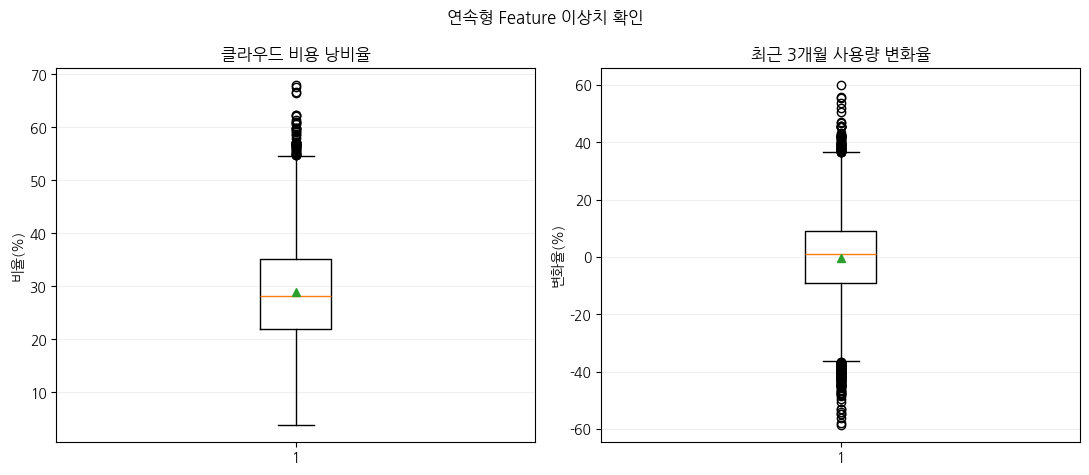

In [45]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-8. 연속형 Feature Boxplot로 이상치 시각화
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-8. 연속형 Feature Boxplot로 이상치 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

axes[0].boxplot(df["cloud_waste_ratio"].dropna() * 100, showmeans=True)
axes[0].set_title("클라우드 비용 낭비율")
axes[0].set_ylabel("비율(%)")
axes[0].grid(axis="y", alpha=0.2)

axes[1].boxplot(df["usage_change_3m"].dropna() * 100, showmeans=True)
axes[1].set_title("최근 3개월 사용량 변화율")
axes[1].set_ylabel("변화율(%)")
axes[1].grid(axis="y", alpha=0.2)

plt.suptitle("연속형 Feature 이상치 확인")
plt.tight_layout()
plt.show()


#### 코드 셀 46 — 팀원용 설명
### 이 셀은 무엇을 하나요?
값이 통계적으로 특이한지를 보는 것이 아니라, **애초에 가능한 범위를 벗어난 잘못된 값이 있는지** 확인합니다.

### 예
- 비용 낭비율은 0~1 범위를 벗어나면 이상
- 장애/지원 수준은 0,1,2,3 이외 값이면 이상

### 결과
`범위 밖 값 개수`가 0이면 데이터 생성 규칙을 벗어난 오류값이 없다는 뜻입니다.

In [46]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-9. 업무적으로 허용 가능한 범위 점검
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-9. 업무적으로 허용 가능한 범위 점검
# 이 범위는 최종 합성데이터 생성 설계에서 허용한 값 범위와 맞는지 확인하는 용도입니다.

range_checks = []

# 비용 낭비율은 0~1 사이여야 함
waste_invalid = ((df["cloud_waste_ratio"].dropna() < 0) | (df["cloud_waste_ratio"].dropna() > 1)).sum()
range_checks.append(["클라우드 비용 낭비율", "0 ~ 1", waste_invalid])

# 사용량 변화율은 합성설계상 -0.65 ~ 0.75 범위
usage_invalid = (
    (df["usage_change_3m"].dropna() < -0.65) |
    (df["usage_change_3m"].dropna() > 0.75)
).sum()
range_checks.append(["최근 3개월 사용량 변화율", "-0.65 ~ 0.75", usage_invalid])

# 장애/지원은 0~3
for col, label in [
    ("service_disruption_level", "서비스 장애 수준"),
    ("support_issue_level", "고객지원 문제 수준")
]:
    s = df[col].dropna()
    invalid = (~s.isin([0,1,2,3])).sum()
    range_checks.append([label, "0, 1, 2, 3", invalid])

range_check_table = pd.DataFrame(
    range_checks,
    columns=["Feature", "허용 범위", "범위 밖 값 개수"]
)

display(range_check_table)


,Feature,허용 범위,범위 밖 값 개수
0,클라우드 비용 낭비율,0 ~ 1,0
1,최근 3개월 사용량 변화율,-0.65 ~ 0.75,0
2,서비스 장애 수준,"0, 1, 2, 3",0
3,고객지원 문제 수준,"0, 1, 2, 3",0



### 이상치 최종 원칙

**이 프로젝트에서는 IQR 이상치를 자동 삭제하지 않는 것이 적절합니다.**

왜냐하면 비용 낭비가 매우 높거나 사용량이 급감한 고객은 모델 입장에서 오히려 **중요한 이탈 위험 고객**이기 때문입니다.

따라서 다음 기준을 사용합니다.

- 허용 범위를 벗어난 값 → **오류 가능성 확인 후 수정/제외**
- 허용 범위 안의 극단값 → **원칙적으로 유지**
- 선형모델에서 극단값 영향이 너무 크다면 → 삭제보다 **RobustScaler / 변환 / Winsorization을 비교 검토**
- Tree 계열 모델(Random Forest, XGBoost 등)에서는 대체로 극단값에 더 강하므로 **원본 유지 우선**


#### 코드 셀 47 — 팀원용 설명
### 이 셀은 무엇을 하나요?
중복을 세 단계로 더 자세히 확인합니다.

1. 같은 `customer_id`
2. ID는 다르지만 Feature+Target이 같은 행
3. 모든 열이 완전히 같은 행

### 핵심
같은 ID는 실제 중복 문제일 수 있지만, 서로 다른 고객이 우연히 같은 Feature 값을 가질 수 있으므로 두 번째 경우는 자동 삭제하면 안 됩니다.

In [47]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-10. 중복 데이터 정밀 점검
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-10. 중복 데이터 정밀 점검

# 1) 고객 ID 완전 중복
id_dup_count = df["customer_id"].duplicated(keep=False).sum()

# 2) ID를 제외한 Feature+Target가 완전히 같은 행
non_id_cols = [c for c in df.columns if c != "customer_id"]
same_feature_rows = df.duplicated(subset=non_id_cols, keep=False)

# 3) 완전히 같은 행 전체
full_dup_count = df.duplicated(keep=False).sum()

duplicate_summary = pd.DataFrame({
    "검사항목": [
        "중복 customer_id가 포함된 행 수",
        "ID 제외 Feature+Target가 완전히 같은 행 수",
        "전체 열이 완전히 같은 중복 행 수"
    ],
    "행 수": [
        id_dup_count,
        same_feature_rows.sum(),
        full_dup_count
    ]
})

display(duplicate_summary)

if id_dup_count == 0:
    print("customer_id 중복 없음 → 동일 고객 중복 등록 문제는 확인되지 않았습니다.")
else:
    print("customer_id 중복 있음 → 해당 고객을 별도로 확인해야 합니다.")


,검사항목,행 수
0,중복 customer_id가 포함된 행 수,0
1,ID 제외 Feature+Target가 완전히 같은 행 수,21
2,전체 열이 완전히 같은 중복 행 수,0


customer_id 중복 없음 → 동일 고객 중복 등록 문제는 확인되지 않았습니다.


#### 코드 셀 48 — 팀원용 설명
### 이 셀은 무엇을 하나요?
ID는 다르지만 Feature와 Target 조합이 완전히 같은 고객이 있다면 실제 예시 행을 보여줍니다.

### 왜 필요한가요?
중복처럼 보이는 행이 정말 잘못된 중복인지, 아니면 서로 다른 고객이 우연히 같은 상태인지 직접 확인하기 위해서입니다.

In [48]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-11. Feature+Target가 우연히 같은 고객이 있는지 예시 확인
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-11. Feature+Target가 우연히 같은 고객이 있는지 예시 확인
same_rows_example = df.loc[same_feature_rows].sort_values(non_id_cols).head(20)

if len(same_rows_example) > 0:
    print("ID는 다르지만 Feature+Target 조합이 같은 고객 예시:")
    display(same_rows_example)
else:
    print("ID를 제외한 모든 값이 완전히 같은 고객 조합은 없습니다.")


ID는 다르지만 Feature+Target 조합이 같은 고객 예시:


,customer_id,industry,company_size,budget_overrun_flag,cloud_waste_ratio,usage_change_3m,service_disruption_level,support_issue_level,renewal_churn
3888,CC-03889,construction_real_estate,small_10_49,NaN,NaN,NaN,NaN,NaN,0
4170,CC-04171,construction_real_estate,small_10_49,NaN,NaN,NaN,NaN,NaN,0
4506,CC-04507,construction_real_estate,small_10_49,NaN,NaN,NaN,NaN,NaN,0
159,CC-00160,healthcare,small_10_49,NaN,NaN,NaN,NaN,NaN,0
3631,CC-03632,healthcare,small_10_49,NaN,NaN,NaN,NaN,NaN,0
3675,CC-03676,it_software,mid_50_249,NaN,NaN,NaN,NaN,NaN,0
4972,CC-04973,it_software,mid_50_249,NaN,NaN,NaN,NaN,NaN,0
25,CC-00026,manufacturing,small_10_49,NaN,NaN,NaN,NaN,NaN,0
286,CC-00287,manufacturing,small_10_49,NaN,NaN,NaN,NaN,NaN,0
1277,CC-01278,manufacturing,small_10_49,NaN,NaN,NaN,NaN,NaN,0



### 중복 최종 원칙

- **`customer_id`가 같은 중복** → 원칙적으로 제거 또는 원천 확인 필요
- **ID는 다르지만 Feature 값이 우연히 같은 고객** → 삭제하면 안 됨
- 실제 기업 데이터에서는 동일 고객의 시점이 다른 기록일 수도 있으므로 **ID와 기준시점까지 함께 확인**하는 것이 필요

이번 합성데이터에서는 고객별 한 행 구조이므로 `customer_id` 중복 여부가 가장 중요한 중복 기준입니다.


#### 코드 셀 49 — 팀원용 설명
### 이 셀은 무엇을 하나요?
모델링 직전에 각 변수를 어떻게 처리할지 **최종 규칙표**로 정리합니다.

### 표에 포함되는 내용
- 모델에 넣을지 여부
- 범주형 변수의 인코딩
- 결측치 대치 방식
- Target 사용 방식

이 표는 팀원들이 이후 모델링 코드를 작성할 때 참고하는 기준표라고 보면 됩니다.

In [49]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-12. 최종 전처리 원칙표
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-12. 최종 전처리 원칙표
preprocess_policy = pd.DataFrame([
    ["customer_id", "식별자", "모델 입력에서는 제외", "고객 식별용이지 예측 정보가 아님"],
    ["industry", "범주형", "유지 + One-Hot Encoding", "업종 세그먼트 정보 유지"],
    ["company_size", "범주형", "유지 + One-Hot Encoding 또는 순서형 처리 비교", "규모별 차이 반영"],
    ["budget_overrun_flag", "0/1", "유지 + 결측은 Train 최빈값", "이진 비용 위험 신호"],
    ["cloud_waste_ratio", "연속형", "유지 + 결측은 Train 중앙값", "비용 효율 정도를 연속적으로 반영"],
    ["usage_change_3m", "연속형", "유지 + 결측은 Train 중앙값", "고객 사용행동 변화 반영"],
    ["service_disruption_level", "0~3 순서형", "유지 + 결측은 Train 최빈값", "장애 심각도 정보 유지"],
    ["support_issue_level", "0~3 순서형", "유지 + 결측은 Train 최빈값", "고객지원 문제 심각도 반영"],
    ["renewal_churn", "Target 0/1", "정답값으로만 사용", "모델의 예측 대상"]
], columns=["변수", "형태", "최종 처리 원칙", "이유"])

display(preprocess_policy)


,변수,형태,최종 처리 원칙,이유
0,customer_id,식별자,모델 입력에서는 제외,고객 식별용이지 예측 정보가 아님
1,industry,범주형,유지 + One-Hot Encoding,업종 세그먼트 정보 유지
2,company_size,범주형,유지 + One-Hot Encoding 또는 순서형 처리 비교,규모별 차이 반영
3,budget_overrun_flag,0/1,유지 + 결측은 Train 최빈값,이진 비용 위험 신호
4,cloud_waste_ratio,연속형,유지 + 결측은 Train 중앙값,비용 효율 정도를 연속적으로 반영
5,usage_change_3m,연속형,유지 + 결측은 Train 중앙값,고객 사용행동 변화 반영
6,service_disruption_level,0~3 순서형,유지 + 결측은 Train 최빈값,장애 심각도 정보 유지
7,support_issue_level,0~3 순서형,유지 + 결측은 Train 최빈값,고객지원 문제 심각도 반영
8,renewal_churn,Target 0/1,정답값으로만 사용,모델의 예측 대상


#### 코드 셀 50 — 팀원용 설명
### 이 셀은 무엇을 하나요?
최종적으로 모델 입력에 사용할 7개 Feature와 Target을 코드 형태로 확정합니다.

### 왜 필요한가요?
이후 Train/Test 분리, 전처리 Pipeline, 모델 학습에서 같은 변수 목록을 반복해서 사용하기 위해서입니다.

### 주의
`customer_id`는 고객을 구분하기 위한 식별자일 뿐 예측 정보가 아니므로 모델 입력에서 제외합니다.

In [50]:
# ------------------------------------------------------------
# 팀원용 코드 읽기 안내
# 목적: 5-13. 모델링 전 사용할 권장 Feature 목록
# 아래 코드는 결과를 재현할 수 있도록 단계별로 작성되어 있습니다.
# 모르는 함수가 있더라도 먼저 '입력 → 계산 → 출력' 흐름으로 보면 됩니다.
# ------------------------------------------------------------

# 5-13. 모델링 전 사용할 권장 Feature 목록
MODEL_FEATURES = [
    "industry",
    "company_size",
    "budget_overrun_flag",
    "cloud_waste_ratio",
    "usage_change_3m",
    "service_disruption_level",
    "support_issue_level"
]

TARGET = "renewal_churn"

print("최종 모델 입력 Feature:")
for i, c in enumerate(MODEL_FEATURES, 1):
    print(f"{i}. {c} ({ko_name[c]})")

print(f"\nTarget: {TARGET} ({ko_name[TARGET]})")
print("\ncustomer_id는 모델 입력에서 제외합니다.")


최종 모델 입력 Feature:
1. industry (업종)
2. company_size (기업 규모)
3. budget_overrun_flag (예산 초과 여부)
4. cloud_waste_ratio (클라우드 비용 낭비율)
5. usage_change_3m (최근 3개월 사용량 변화율)
6. service_disruption_level (서비스 장애 수준)
7. support_issue_level (고객지원 문제 수준)

Target: renewal_churn (재계약 이탈)

customer_id는 모델 입력에서 제외합니다.



# 최종 결론 — 2·3·4·5단계 EDA 완료

## 2. Target 불균형
- 이탈 고객이 유지 고객보다 적으므로 **Accuracy 단독 평가 금지**
- 향후 모델 평가는 **Recall, Precision, F1-score, ROC-AUC, PR-AUC**를 함께 사용
- Train/Test 분리 시 **`stratify=y`** 사용 권장

## 3. Target ↔ Feature
- 업종, 규모, 비용, 사용량, 장애, 고객지원별 이탈률을 각각 확인
- 범주형은 교차표·피벗·카이제곱·Cramer's V
- 연속형은 분포·Boxplot·구간별 이탈률·Mann–Whitney U 검정
- 두 Feature를 동시에 보는 교차 피벗과 이탈률 히트맵까지 확인

## 4. Feature ↔ Feature
- Spearman 상관계수와 히트맵
- 범주형 Cramer's V
- VIF 다중공선성
- 높은 중복 후보 자동 탐색
- 현재 7개 주요 Feature는 **업무적 의미가 서로 달라 모두 유지하는 것이 합리적**

## 5. 결측 · 이상치 · 중복
- 결측은 삭제보다 **Train 기준 대치**가 기본
- 연속형 → 중앙값 / 0·1 및 순서형 → 최빈값
- 결측 여부 자체가 의미가 있으면 missing indicator 추가 검토
- 허용 범위 안의 극단값은 **이탈 위험 신호일 수 있으므로 자동 삭제하지 않음**
- `customer_id`가 같은 중복만 실제 중복으로 우선 판단
- ID가 다르고 Feature 값만 같은 행은 임의 삭제하지 않음

---

## 모델링 직전 최종 상태

**유지 Feature 7개**

1. 업종
2. 기업 규모
3. 예산 초과 여부
4. 클라우드 비용 낭비율
5. 최근 3개월 사용량 변화율
6. 서비스 장애 수준
7. 고객지원 문제 수준

**Target**

- 재계약 이탈 여부 (`renewal_churn`)

이제 다음 단계는 **Train / Validation / Test 분리 → 전처리 Pipeline → Baseline 모델 → 여러 모델 비교**입니다.



# 팀원에게 공유할 때 권장 읽는 순서

이 노트북을 처음 보는 팀원은 코드를 처음부터 모두 이해하려고 하기보다 아래 순서로 보는 것이 좋습니다.

1. **각 코드 셀 위의 ‘팀원용 설명’부터 읽기**
2. 코드에서 `#`으로 시작하는 한국어 주석 확인
3. 실행 결과의 **표 제목 / 그래프 제목 / 축 이름** 확인
4. 유지(0)와 이탈(1)의 차이가 있는지 확인
5. 마지막 **전처리 원칙표와 최종 Feature 목록** 확인

### 꼭 기억할 것
- 이 데이터는 실제 고객 원천데이터가 아니라 **외부근거를 참고해 만든 합성데이터**입니다.
- 따라서 EDA 결과는 “실제 시장의 법칙을 발견했다”는 의미가 아니라  
  **합성데이터가 우리가 의도한 현실적인 구조를 갖고 있는지 검증한 결과**입니다.
- 향후 실제 기업 데이터가 확보되면 동일한 EDA를 다시 수행해야 합니다.
